# Statistical Learning and Data Analytics for Transportation Systems
## Problem Set 3: Neural Networks, Reinforcement Learning, Convolutions

**Name:** Mohd Zamin Quadri

This notebook holds the code, outputs and figures behind the report and follows the
problem sheet's numbering. Every number quoted in the report is produced by a cell
here; nothing is transcribed by hand.

Paths are relative to the folder containing this notebook. Figures are written to
`figures/` and tables to `results/`. Every value quoted in the report is also
collected into `results/reported_values.csv`, so the report can be checked
against the notebook one number at a time.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

FIG_DIR, RES_DIR = Path("figures"), Path("results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.grid": True, "grid.alpha": 0.3,
})
pd.set_option("display.width", 160)

REPORTED = []


def record(problem, metric, value, note=""):
    """Record a value that appears in the report, and return it unchanged."""
    REPORTED.append({"problem": problem, "metric": metric, "value": value,
                     "note": note})
    return value


def save(fig, name):
    fig.savefig(FIG_DIR / name)
    print(f"saved -> {FIG_DIR / name}")


def find_data(filename):
    """Locate a supplied data file without hard-coding an absolute path."""
    for candidate in (Path("data") / filename, Path(filename),
                      Path("..") / filename):
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found near {Path.cwd()}")

# Problem 1: Multilayer Perceptron (15 points)

The MLP is a one-hidden-layer network with sigmoid activations at both layers and a
binary cross-entropy loss, trained by full-batch gradient descent. Writing $N$ for the
number of samples, $n_x$ for the input width and $n_h$ for the hidden width:

$$A_1 = XW_1 + \mathbf{1}b_1,\qquad Z_1=\sigma(A_1),\qquad
  A_2 = Z_1W_2 + \mathbf{1}b_2,\qquad \hat{Y}=\sigma(A_2)$$

| object | shape | | object | shape |
|---|---|---|---|---|
| $X$ | $(N, n_x)$ | | $W_2$ | $(n_h, 1)$ |
| $W_1$ | $(n_x, n_h)$ | | $b_2$ | $(1,1)$ |
| $b_1$ | $(1, n_h)$ | | $A_2,\hat{Y},y$ | $(N,1)$ |
| $A_1, Z_1$ | $(N, n_h)$ | | | |

with $\sigma(a)=1/(1+e^{-a})$ and $\sigma'(a)=\sigma(a)\big(1-\sigma(a)\big)$, and

$$L = -\frac{1}{N}\sum_{i=1}^{N}\Big[y_i\ln\hat y_i + (1-y_i)\ln(1-\hat y_i)\Big].$$

## 1.1 Gradient derivation and completion of `mlp.py`

**Step 1: loss with respect to the output.**

$$\frac{\partial L}{\partial \hat y_i}
= -\frac{1}{N}\left[\frac{y_i}{\hat y_i}-\frac{1-y_i}{1-\hat y_i}\right]
= -\frac{1}{N}\cdot\frac{y_i(1-\hat y_i)-(1-y_i)\hat y_i}{\hat y_i(1-\hat y_i)}
= \frac{1}{N}\cdot\frac{\hat y_i-y_i}{\hat y_i(1-\hat y_i)}$$

**Step 2: through the output sigmoid.** With $\hat y_i=\sigma(a_{2,i})$ we have
$\partial\hat y_i/\partial a_{2,i}=\hat y_i(1-\hat y_i)$, so

$$\delta_{2,i}\;=\;\frac{\partial L}{\partial a_{2,i}}
\;=\;\frac{1}{N}\cdot\frac{\hat y_i-y_i}{\hat y_i(1-\hat y_i)}\cdot\hat y_i(1-\hat y_i)
\;=\;\frac{\hat y_i-y_i}{N}.$$

The factor $\hat y(1-\hat y)$ cancels exactly. This is the reason sigmoid output and
cross-entropy are paired: no saturation term survives at the output layer, so a
confidently wrong prediction still produces a large gradient. Squared error would
leave the factor in place and learning would stall.

**Step 3: output-layer parameters.** From $a_{2,i}=\sum_j z_{1,ij}W_{2,j}+b_2$,

$$\nabla_{W_2}L = Z_1^{\top}\delta_2 \;\;(n_h,1),
\qquad \nabla_{b_2}L = \sum_i \delta_{2,i}\;\;(1,1).$$

The bias gradient is a sum over the batch because $b_2$ was broadcast across all $N$
rows in the forward pass: broadcasting forwards becomes summation backwards.

**Step 4: into the hidden layer.**

$$\nabla_{Z_1}L=\delta_2W_2^{\top}\;\;(N,n_h),\qquad
\delta_{1,ij}=\big(\nabla_{Z_1}L\big)_{ij}\,z_{1,ij}\big(1-z_{1,ij}\big).$$

**Step 5: hidden-layer parameters.**

$$\nabla_{W_1}L=X^{\top}\delta_1\;\;(n_x,n_h),\qquad
\nabla_{b_1}L=\sum_i\delta_{1,i\cdot}\;\;(1,n_h).$$

**Step 6: update.** $\theta\leftarrow\theta-\eta\nabla_\theta L$ for each parameter.

Three details decide whether the code matches this derivation:

1. `backward_propagation` calls `activation_derivative(out)` and
   `activation_derivative(self.z1)`, both **post**-activation values, despite the
   argument being named `a`. The correct body is therefore $z(1-z)$, not
   $\sigma(a)(1-\sigma(a))$.
2. The loss uses `np.mean`, so the $1/N$ must be carried into
   `binary_cross_entropy_derivative`; otherwise gradient magnitude scales with batch
   size.
3. Bias gradients use `sum(axis=0, keepdims=True)`, preserving the $(1,\cdot)$ shape.

In [2]:
import inspect

from mlp import MLP

for name in ("activation_derivative", "forward_propagation",
             "binary_cross_entropy_derivative", "backward_propagation",
             "update_weights"):
    print(inspect.getsource(getattr(MLP, name)))

    def activation_derivative(self, a):
        ### YOUR CODE STARTS HERE ###
        # backward_propagation passes the *activation output* z = sigma(a), not the
        # pre-activation. Written in terms of its own output, sigma' = z (1 - z).
        return a * (1 - a)
        ### YOUR CODE ENDS HERE ###

    def forward_propagation(self, X):
        self.a1 = X @ self.W1 + self.b1
        self.z1 = self.activation(self.a1)
        ### YOUR CODE STARTS HERE ###
        self.a2 = self.z1 @ self.W2 + self.b2
        self.out = self.activation(self.a2)
        return self.out
        ### YOUR CODE ENDS HERE ###

    def binary_cross_entropy_derivative(self, y, out):
        ### YOUR CODE STARTS HERE ###
        # d/dout of the *mean* loss, so the 1/N of np.mean has to be carried along.
        out = np.clip(out, EPS, 1 - EPS)
        return (out - y) / (y.size * out * (1 - out))
        ### YOUR CODE ENDS HERE ###

    def backward_propagation(self, X, y, out):
        # ∇L_out
        g

### Verification 1: finite differences and autograd

Correctness of the derivation is established independently of whether training
succeeds: central differences against the analytic gradient, then a PyTorch autograd
cross-check on identical weights.

In [3]:
def analytic_grads(net, X, y):
    """Run one backward pass and capture the gradients instead of applying them."""
    out = net.forward_propagation(X)
    g = {}
    original = net.update_weights
    net.update_weights = lambda gW2, gb2, gW1, gb1: g.update(
        W2=gW2, b2=gb2, W1=gW1, b1=gb1)
    net.backward_propagation(X, y, out)
    net.update_weights = original
    return g


def numeric_grads(net, X, y, eps=1e-6):
    """Central differences on the full objective, including any L2 term."""
    num = {}
    for name in ("W1", "b1", "W2", "b2"):
        P = getattr(net, name)
        G = np.zeros_like(P)
        it = np.nditer(P, flags=["multi_index"])
        while not it.finished:
            i = it.multi_index
            o = P[i]
            P[i] = o + eps
            lp = net.total_loss(y, net.forward_propagation(X))
            P[i] = o - eps
            lm = net.total_loss(y, net.forward_propagation(X))
            P[i] = o
            G[i] = (lp - lm) / (2 * eps)
            it.iternext()
        num[name] = G
    return num


rng = np.random.default_rng(0)
Xg = rng.normal(size=(7, 3))
yg = rng.integers(0, 2, size=(7, 1)).astype(float)

np.random.seed(1)
net = MLP(3, 4, 1, learning_rate=0.0)          # lr = 0 keeps the weights fixed
ga, gn = analytic_grads(net, Xg, yg), numeric_grads(net, Xg, yg)

rows = []
for k in ("W1", "b1", "W2", "b2"):
    rel = np.abs(ga[k] - gn[k]).max() / max(np.abs(gn[k]).max(), 1e-12)
    rows.append({"parameter": k, "shape": str(ga[k].shape), "max_rel_error": rel})
gradcheck = pd.DataFrame(rows)
print(gradcheck.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
record("1.1", "gradient_check_max_rel_error", float(gradcheck.max_rel_error.max()),
    "central differences, eps=1e-6")

parameter  shape  max_rel_error
       W1 (3, 4)      5.115e-10
       b1 (1, 4)      2.615e-09
       W2 (4, 1)      2.282e-10
       b2 (1, 1)      5.097e-09


5.096971201668568e-09

In [4]:
import torch

tX = torch.tensor(Xg, dtype=torch.float64)
ty = torch.tensor(yg, dtype=torch.float64)
tp = {k: torch.tensor(getattr(net, k).copy(), requires_grad=True)
      for k in ("W1", "b1", "W2", "b2")}
z1 = torch.sigmoid(tX @ tp["W1"] + tp["b1"])
o = torch.sigmoid(z1 @ tp["W2"] + tp["b2"])
(-(ty * torch.log(o) + (1 - ty) * torch.log(1 - o)).mean()).backward()

worst = max(np.abs(ga[k] - tp[k].grad.numpy()).max() for k in tp)
print(f"max |analytic - autograd| over all parameters: {worst:.3e}")
record("1.1", "autograd_max_abs_diff", float(worst), "PyTorch float64 cross-check")

max |analytic - autograd| over all parameters: 2.776e-17


2.7755575615628914e-17

### Training with the settings supplied in the test snippet

In [5]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

X, y = make_circles(200, noise=0.1, random_state=RANDOM_STATE)
y = y[:, np.newaxis]
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE)

balance = pd.DataFrame({
    "subset": ["full", "train", "test"],
    "n": [len(y), len(y_tr), len(y_te)],
    "class_1": [int(y.sum()), int(y_tr.sum()), int(y_te.sum())],
    "class_0": [int((1 - y).sum()), int((1 - y_tr).sum()), int((1 - y_te).sum())],
})
balance["majority_share"] = (balance[["class_0", "class_1"]].max(axis=1)
                             / balance["n"])
print(balance.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
record("1.1", "test_majority_baseline", float(balance.majority_share.iloc[-1]),
    "majority-class accuracy on the 60 test points")

subset   n  class_1  class_0  majority_share
  full 200      100      100          0.5000
 train 140       72       68          0.5143
  test  60       28       32          0.5333


0.5333333333333333

In [6]:
np.random.seed(RANDOM_STATE)          # init_parameters draws from np.random
mlp_default = MLP(input_size=2, hidden_size=8, output_size=1, learning_rate=0.001)
hist_default = mlp_default.fit(X_tr, y_tr, epochs=20000, verbose=False)

acc_tr = float(np.mean(mlp_default.predict(X_tr) == y_tr))
acc_te = float(np.mean(mlp_default.predict(X_te) == y_te))
print(f"loss epoch 0      {hist_default[0]:.6f}")
print(f"loss epoch 19999  {hist_default[-1]:.6f}     ln 2 = {np.log(2):.6f}")
print(f"monotone decrease {bool(np.all(np.diff(hist_default) < 0))}")
print(f"train accuracy    {acc_tr:.2%}")
print(f"test  accuracy    {acc_te:.2%}")

record("1.1", "default_final_train_loss", float(hist_default[-1]), "lr=0.001, 20000 ep")
record("1.1", "default_train_accuracy", acc_tr, "lr=0.001")
record("1.1", "default_test_accuracy", acc_te, "lr=0.001")

loss epoch 0      1.016278
loss epoch 19999  0.690279     ln 2 = 0.693147
monotone decrease True
train accuracy    55.00%
test  accuracy    38.33%


0.38333333333333336

The gradients are exact, yet the network does not learn: the loss settles at
$\ln 2 = 0.6931$, the loss of a constant $0.5$ predictor. The cause is the step size.
The largest gradient component at initialisation is of order $10^{-1}$, so with
$\eta=10^{-3}$ no weight moves by more than about $3\times10^{-4}$ per epoch and after
20 000 full-batch steps the parameters have barely left their initial values. A sweep
over $\eta$ confirms that the learning rate, not the architecture or the gradient, is
the binding constraint.

In [7]:
sweep = []
for lr in (0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0):
    np.random.seed(RANDOM_STATE)
    m = MLP(2, 8, 1, learning_rate=lr)
    with np.errstate(over="ignore", invalid="ignore"):
        h = m.fit(X_tr, y_tr, epochs=20000, verbose=False)
        sweep.append({
            "learning_rate": lr,
            "final_train_loss": h[-1],
            "train_acc": float(np.mean(m.predict(X_tr) == y_tr)),
            "test_acc": float(np.mean(m.predict(X_te) == y_te)),
            "diverged": not np.isfinite(h[-1]),
        })
sweep = pd.DataFrame(sweep)
sweep.to_csv(RES_DIR / "p1_1_lr_sweep.csv", index=False)
print(sweep.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

best_sweep_lr = float(sweep.loc[sweep.final_train_loss.idxmin(), "learning_rate"])
record("1.1", "sweep_best_learning_rate", best_sweep_lr, "lowest final training loss")

 learning_rate  final_train_loss  train_acc  test_acc  diverged
        0.0010            0.6903     0.5500    0.3833     False
        0.0100            0.6856     0.5500    0.4000     False
        0.1000            0.3848     0.8429    0.7833     False
        1.0000            0.2725     0.8786    0.8167     False
        5.0000            0.2880     0.8571    0.7833     False
       10.0000            0.2623     0.8571    0.7833     False
       20.0000            0.6752     0.8000    0.6833     False
       50.0000           13.4208     0.5143    0.4667     False


10.0

### Figure: classification of the test data

saved -> figures\p1_1_test_classification.png


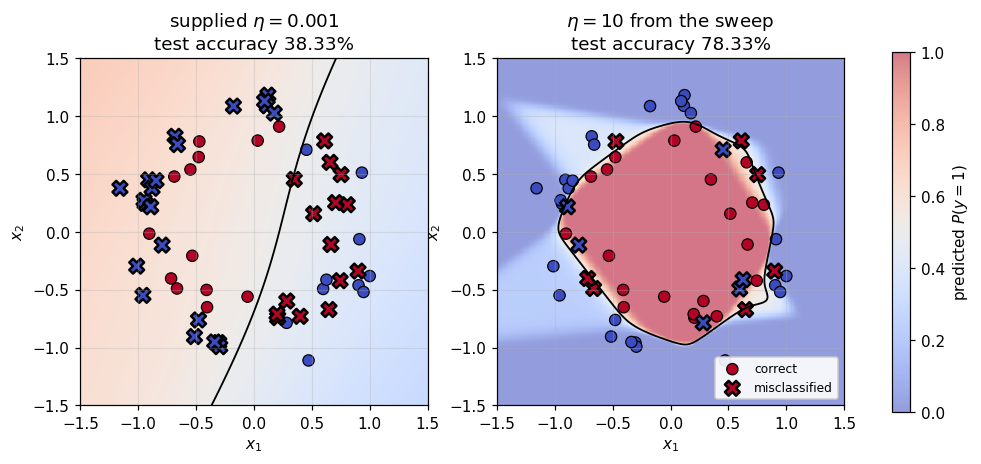

In [8]:
def decision_panel(ax, model, title):
    """Decision surface with the 60 test points, correct vs misclassified."""
    gx, gy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
    with np.errstate(over="ignore", invalid="ignore"):
        surf = model.forward_propagation(np.c_[gx.ravel(), gy.ravel()])
    pcm = ax.pcolormesh(gx, gy, surf.reshape(gx.shape), cmap="coolwarm",
                        vmin=0, vmax=1, alpha=0.55, shading="auto")
    ax.contour(gx, gy, surf.reshape(gx.shape), levels=[0.5], colors="k",
               linewidths=1.2)

    pred = model.predict(X_te)
    ok = (pred == y_te).ravel()
    ax.scatter(X_te[ok, 0], X_te[ok, 1], c=y_te[ok].ravel(), cmap="coolwarm",
               vmin=0, vmax=1, ec="black", s=55, lw=0.8, label="correct")
    ax.scatter(X_te[~ok, 0], X_te[~ok, 1], c=y_te[~ok].ravel(), cmap="coolwarm",
               vmin=0, vmax=1, ec="black", s=95, lw=1.6, marker="X",
               label="misclassified")
    ax.set(title=title, xlabel="$x_1$", ylabel="$x_2$",
           xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))
    ax.set_aspect("equal")
    return pcm


np.random.seed(RANDOM_STATE)
mlp_sweep = MLP(2, 8, 1, learning_rate=best_sweep_lr)
mlp_sweep.fit(X_tr, y_tr, epochs=20000, verbose=False)
acc_sweep = float(np.mean(mlp_sweep.predict(X_te) == y_te))
record("1.1", "sweep_best_test_accuracy", acc_sweep, f"lr={best_sweep_lr}")

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.0))
pcm = decision_panel(axes[0], mlp_default,
                     f"supplied $\\eta = 0.001$\ntest accuracy {acc_te:.2%}")
decision_panel(axes[1], mlp_sweep,
               f"$\\eta = {best_sweep_lr:g}$ from the sweep\n"
               f"test accuracy {acc_sweep:.2%}")
axes[1].legend(loc="lower right", fontsize=8, framealpha=0.9)
fig.colorbar(pcm, ax=axes, shrink=0.85, label="predicted $P(y=1)$")
save(fig, "p1_1_test_classification.png")
plt.show()

**Figure 1.** Classification of the 60 held-out test points by the completed MLP.
Background shading is the predicted probability $P(y=1)$, the black line the $0.5$
decision boundary. Circles mark correctly classified test points, crosses
misclassified ones. Left: the learning rate supplied in the test snippet; the network
has not moved away from its initialisation and predicts almost the same probability
everywhere. Right: the same code and the same seed with a learning rate taken from
the sweep, which recovers the circular boundary. Problem 1.2 replaces this manual
choice with an automated search.

## 1.2 Tuning `learning_rate` and `alpha` by Bayesian optimization

**An assumption, stated before it is used.** The supplied `MLP` class defines no
training hyperparameter called $\alpha$. The only `alpha` in `mlp.py` is
`plt.pcolormesh(..., alpha=0.5)` in the test snippet, which controls plot
transparency and has nothing to do with training. Since the problem asks to optimise
a hyperparameter the code does not contain, an interpretation is unavoidable, so I
make mine explicit: **I take $\alpha$ to be the coefficient of an $L_2$ penalty on
the network weights**, the usual meaning of `alpha` in `sklearn`'s `MLPClassifier`
and in ridge regression. The extension is backward-compatible: $\alpha=0$ recovers
the supplied unregularised model exactly, so nothing in 1.1 is affected.

I use an $L_2$ penalty on the weights, leaving the biases unpenalised:

$$J \;=\; L \;+\; \frac{\alpha}{2}\Big(\lVert W_1\rVert_F^2+\lVert W_2\rVert_F^2\Big).$$

The penalty involves no forward-pass quantity, so it adds to the gradient
independently of backpropagation:

$$\frac{\partial}{\partial W_{jk}}\left[\frac{\alpha}{2}\sum_{j'k'}W_{j'k'}^2\right]
= \alpha W_{jk}
\quad\Longrightarrow\quad
\nabla_{W_2}J = Z_1^{\top}\delta_2+\alpha W_2,\qquad
\nabla_{W_1}J = X^{\top}\delta_1+\alpha W_1,$$

with the bias gradients unchanged. Biases are excluded because a bias shifts the
decision boundary without controlling how sharply the network responds to its inputs,
so penalising it biases the model toward predicting $0.5$ without reducing capacity.

`alpha` defaults to `0.0`, so every 1.1 result above is the unregularised model.

In [9]:
ALPHA_CHECK = 0.37          # deliberately not a round number

np.random.seed(1)
net_reg = MLP(3, 4, 1, learning_rate=0.0, alpha=ALPHA_CHECK)
ga_r, gn_r = analytic_grads(net_reg, Xg, yg), numeric_grads(net_reg, Xg, yg)

tp = {k: torch.tensor(getattr(net_reg, k).copy(), requires_grad=True)
      for k in ("W1", "b1", "W2", "b2")}
z1 = torch.sigmoid(tX @ tp["W1"] + tp["b1"])
o = torch.sigmoid(z1 @ tp["W2"] + tp["b2"])
(-(ty * torch.log(o) + (1 - ty) * torch.log(1 - o)).mean()
 + 0.5 * ALPHA_CHECK * ((tp["W1"] ** 2).sum() + (tp["W2"] ** 2).sum())).backward()

rows = []
for k in ("W1", "b1", "W2", "b2"):
    rows.append({
        "parameter": k,
        "fd_max_rel_error": np.abs(ga_r[k] - gn_r[k]).max()
        / max(np.abs(gn_r[k]).max(), 1e-12),
        "autograd_max_abs_diff": np.abs(ga_r[k] - tp[k].grad.numpy()).max(),
    })
gradcheck_l2 = pd.DataFrame(rows)
print(f"regularised gradient check, alpha = {ALPHA_CHECK}")
print(gradcheck_l2.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
record("1.2", "l2_gradient_check_max_rel_error",
    float(gradcheck_l2.fd_max_rel_error.max()), "central differences")
record("1.2", "l2_autograd_max_abs_diff",
    float(gradcheck_l2.autograd_max_abs_diff.max()), "PyTorch float64")

regularised gradient check, alpha = 0.37
parameter  fd_max_rel_error  autograd_max_abs_diff
       W1         8.024e-10              1.110e-16
       b1         7.400e-09              1.388e-17
       W2         1.055e-09              1.110e-16
       b2         8.624e-09              1.388e-17


1.1102230246251565e-16

### The objective and the search space

Two distinct quantities appear below and are kept apart everywhere:

| symbol | meaning |
|---|---|
| $L_{cv}$ | mean 3-fold cross-validated binary cross-entropy (**raw**) |
| $g=\log_{10}L_{cv}$ | the transformed value the optimiser minimises |

Design choices and why:

* **Validation loss, not accuracy.** With 47 validation points per fold, accuracy takes
  a small number of discrete values and is a step function of the hyperparameters, so
  a Gaussian process cannot model it usefully. Cross-entropy is continuous. The
  consequence, reported honestly below, is that the selected model optimises
  calibration rather than raw accuracy.
* **Cross-validation on the training partition only.** The 60 test points are used
  exactly once, at the very end.
* **A fixed initialisation seed per fold**, which makes the objective deterministic in
  $(\eta,\alpha)$, verified by re-evaluating a point and recovering the same value.
* **$\log_{10}$ transform**, so that configurations which diverge do not dominate the
  surrogate fit as outliers.
* **A logarithmic search box**, $\log_{10}\eta\in[-3,1]$ and
  $\log_{10}\alpha\in[-6,0]$: the sweep in 1.1 showed the usable band spans four
  orders of magnitude, so a linear box would spend nearly all its budget in one corner.
* Configurations whose weights become non-finite, or whose loss exceeds
  $L_{\text{cap}}=10$, are recorded at that cap so the surrogate learns the region is
  bad without a single extreme value distorting it.

In [10]:
from scipy.optimize import minimize
from scipy.stats import norm, qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
from sklearn.model_selection import StratifiedKFold

EPOCHS, HIDDEN, N_FOLDS = 20000, 8, 3
N_INIT, N_ITER, XI, CAP = 16, 34, 0.01, 10.0
BUDGET = N_INIT + N_ITER
BOUNDS = np.array([[-3.0, 1.0],      # log10 learning_rate
                   [-6.0, 0.0]])     # log10 alpha

folds = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
             .split(X_tr, y_tr.ravel()))
n_capped = {"count": 0}


def cv_loss(log_lr, log_alpha):
    """Raw objective L_cv: mean 3-fold validation cross-entropy."""
    lr, a = 10.0 ** log_lr, 10.0 ** log_alpha
    losses = []
    for k, (i_fit, i_val) in enumerate(folds):
        np.random.seed(RANDOM_STATE + k)
        net = MLP(2, HIDDEN, 1, learning_rate=lr, alpha=a)
        with np.errstate(over="ignore", invalid="ignore"):
            net.fit(X_tr[i_fit], y_tr[i_fit], epochs=EPOCHS, verbose=False)
            losses.append(net.binary_cross_entropy_loss(
                y_tr[i_val], net.forward_propagation(X_tr[i_val])))
    m = np.mean(losses)
    if not np.isfinite(m) or m > CAP:
        n_capped["count"] += 1
        m = CAP
    return float(m)


def objective(log_lr, log_alpha):
    """Transformed objective g = log10(L_cv)."""
    return float(np.log10(cv_loss(log_lr, log_alpha)))


def to_box(U):
    return BOUNDS[:, 0] + U * (BOUNDS[:, 1] - BOUNDS[:, 0])


def expected_improvement(Xc, gp, g_best):
    """EI for minimisation: E[max(g_best - g(x) - xi, 0)] under the GP posterior."""
    mu, sd = gp.predict(Xc, return_std=True)
    imp = g_best - mu - XI
    with np.errstate(divide="ignore", invalid="ignore"):
        Z = imp / sd
        ei = imp * norm.cdf(Z) + sd * norm.pdf(Z)
    return np.where(sd > 0, ei, 0.0)

The surrogate is a Gaussian process with a Matérn $\nu=5/2$ kernel and separate length
scales per dimension. The upper bound on those length scales is capped at 10: the box
is only 4 by 6 units wide in log space, so a length scale of 10 already corresponds to
an almost linear trend, and allowing larger values lets the GP declare a dimension
irrelevant and stop searching it.

In [11]:
def run_bo(progress_every=10):
    Xs = to_box(qmc.Sobol(2, scramble=True, seed=RANDOM_STATE).random(N_INIT))
    gs = np.array([objective(*p) for p in Xs])
    print(f"  Sobol initialisation done ({N_INIT} evaluations), "
          f"best g = {gs.min():+.4f}", flush=True)
    kernel = (ConstantKernel(1.0, (1e-3, 1e3))
              * Matern([1.0, 1.0], (1e-2, 1e1), nu=2.5))
    for it in range(N_ITER):
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                                      n_restarts_optimizer=5,
                                      random_state=RANDOM_STATE).fit(Xs, gs)
        cand = to_box(qmc.Sobol(2, scramble=True,
                                seed=RANDOM_STATE + it).random(4096))
        ei = expected_improvement(cand, gp, gs.min())
        x_next, best_ei = cand[ei.argmax()], ei.max()
        res = minimize(lambda p: -expected_improvement(p[None], gp, gs.min())[0],
                       x_next, bounds=BOUNDS, method="L-BFGS-B")
        if res.success and -res.fun > best_ei:
            x_next = res.x
        Xs = np.vstack([Xs, x_next])
        gs = np.append(gs, objective(*x_next))
        if (it + 1) % progress_every == 0:
            print(f"  guided iteration {it + 1:2d}/{N_ITER}, "
                  f"best g = {gs.min():+.4f}", flush=True)
    return Xs, gs


t0 = time.perf_counter()
bo_X, bo_g = run_bo()
bo_secs = time.perf_counter() - t0
print(f"Bayesian optimization: {BUDGET} evaluations in {bo_secs:.0f} s, "
      f"{n_capped['count']} at the cap")

i_bo = int(bo_g.argmin())
lr_bo, al_bo = 10.0 ** bo_X[i_bo, 0], 10.0 ** bo_X[i_bo, 1]
print(f"best  learning_rate = {lr_bo:.4g}   alpha = {al_bo:.4g}")
print(f"      g = {bo_g[i_bo]:+.4f}   L_cv = {10 ** bo_g[i_bo]:.4f}")

record("1.2", "bo_learning_rate", float(lr_bo), "BO optimum")
record("1.2", "bo_alpha", float(al_bo), "BO optimum")
record("1.2", "bo_g", float(bo_g[i_bo]), "log10 of CV cross-entropy")
record("1.2", "bo_L_cv", float(10 ** bo_g[i_bo]), "raw CV cross-entropy")
record("1.2", "bo_runtime_s", float(bo_secs), f"{BUDGET} evaluations")

  Sobol initialisation done (16 evaluations), best g = -0.3486


  guided iteration 10/34, best g = -0.3522


  guided iteration 20/34, best g = -0.3701


  guided iteration 30/34, best g = -0.3710


Bayesian optimization: 50 evaluations in 324 s, 1 at the cap
best  learning_rate = 2.223   alpha = 0.0003749
      g = -0.3712   L_cv = 0.4254


324.3291953000007

### Control: random search with an identical budget

Bayesian optimization is only worth its complexity if it beats an uninformed search of
the same size, so the identical objective is evaluated at `BUDGET` uniformly random
points of the same log-scaled box.

In [12]:
n_capped["count"] = 0
rs_X = to_box(np.random.default_rng(RANDOM_STATE).random((BUDGET, 2)))
t0 = time.perf_counter()
rs_g = np.array([objective(*p) for p in rs_X])
rs_secs = time.perf_counter() - t0

i_rs = int(rs_g.argmin())
lr_rs, al_rs = 10.0 ** rs_X[i_rs, 0], 10.0 ** rs_X[i_rs, 1]
print(f"random search: {BUDGET} evaluations in {rs_secs:.0f} s")
print(f"best  learning_rate = {lr_rs:.4g}   alpha = {al_rs:.4g}")
print(f"      g = {rs_g[i_rs]:+.4f}   L_cv = {10 ** rs_g[i_rs]:.4f}")

record("1.2", "rs_learning_rate", float(lr_rs), "random-search optimum")
record("1.2", "rs_alpha", float(al_rs), "random-search optimum")
record("1.2", "rs_L_cv", float(10 ** rs_g[i_rs]), "raw CV cross-entropy")

random search: 50 evaluations in 323 s
best  learning_rate = 1.247   alpha = 0.0004298
      g = -0.3714   L_cv = 0.4252


0.42519548374195937

In [13]:
# How much of the random-search result is luck? Bootstrap the best-of-k curve
# from the BUDGET independent draws.
boot_rng = np.random.default_rng(0)
draws = boot_rng.choice(rs_g, size=(10000, BUDGET), replace=True)
rs_boot = np.minimum.accumulate(draws, axis=1)
rs_med = np.median(rs_boot, axis=0)
rs_lo, rs_hi = np.percentile(rs_boot, [10, 90], axis=0)

p_single = float((rs_g <= rs_g[i_rs]).mean())
print(f"random search's best point was drawn at position {i_rs + 1} of {BUDGET}")
print(f"share of single draws at least that good: {p_single:.0%}")

ridge = -0.34          # g threshold; L_cv <= 10**-0.34
print(f"\nevaluations with g <= {ridge} (L_cv <= {10 ** ridge:.4f}):")
print(f"  BO  {int((bo_g <= ridge).sum())}/{BUDGET}"
      f"   of which guided {int((bo_g[N_INIT:] <= ridge).sum())}/{N_ITER},"
      f" Sobol init {int((bo_g[:N_INIT] <= ridge).sum())}/{N_INIT}")
print(f"  RS  {int((rs_g <= ridge).sum())}/{BUDGET}")

record("1.2", "bo_evals_in_good_region", int((bo_g <= ridge).sum()), f"g <= {ridge}")
record("1.2", "bo_guided_evals_in_good_region", int((bo_g[N_INIT:] <= ridge).sum()),
    f"of {N_ITER} guided iterations")
record("1.2", "rs_evals_in_good_region", int((rs_g <= ridge).sum()), f"g <= {ridge}")

random search's best point was drawn at position 1 of 50
share of single draws at least that good: 2%

evaluations with g <= -0.34 (L_cv <= 0.4571):
  BO  16/50   of which guided 15/34, Sobol init 1/16
  RS  6/50


6

saved -> figures\p1_2_bo_convergence.png


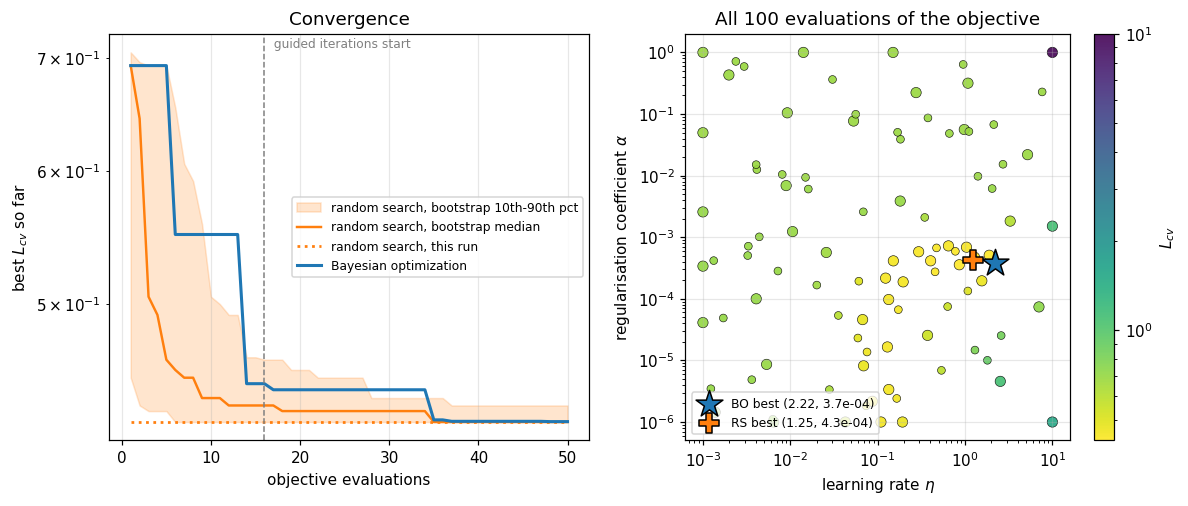

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))

ax = axes[0]
k = np.arange(1, BUDGET + 1)
ax.fill_between(k, 10 ** rs_lo, 10 ** rs_hi, color="tab:orange", alpha=0.20,
                label="random search, bootstrap 10th-90th pct")
ax.plot(k, 10 ** rs_med, color="tab:orange", lw=1.6,
        label="random search, bootstrap median")
ax.plot(k, 10 ** np.minimum.accumulate(rs_g), color="tab:orange", ls=":", lw=1.8,
        label="random search, this run")
ax.plot(k, 10 ** np.minimum.accumulate(bo_g), color="tab:blue", lw=2.0,
        label="Bayesian optimization")
ax.axvline(N_INIT, color="grey", ls="--", lw=1)
ax.text(N_INIT + 0.6, ax.get_ylim()[1], " guided iterations start", va="top",
        fontsize=8, color="grey")
ax.set(xlabel="objective evaluations", ylabel="best $L_{cv}$ so far",
       title="Convergence", yscale="log")
ax.legend(fontsize=8)

ax = axes[1]
sc = ax.scatter(10 ** np.r_[bo_X[:, 0], rs_X[:, 0]],
                10 ** np.r_[bo_X[:, 1], rs_X[:, 1]],
                c=10 ** np.r_[bo_g, rs_g], norm="log", cmap="viridis_r",
                s=np.r_[np.full(BUDGET, 46), np.full(BUDGET, 26)],
                marker="o", ec="black", lw=0.4, alpha=0.9)
ax.scatter([lr_bo], [al_bo], marker="*", s=340, c="tab:blue", ec="black", lw=1.0,
           label=f"BO best ({lr_bo:.2f}, {al_bo:.1e})", zorder=5)
ax.scatter([lr_rs], [al_rs], marker="P", s=180, c="tab:orange", ec="black", lw=1.0,
           label=f"RS best ({lr_rs:.2f}, {al_rs:.1e})", zorder=5)
ax.set(xscale="log", yscale="log", xlabel="learning rate $\\eta$",
       ylabel=r"regularisation coefficient $\alpha$",
       title="All 100 evaluations of the objective")
ax.legend(fontsize=8, loc="lower left")
fig.colorbar(sc, ax=ax, label="$L_{cv}$")
save(fig, "p1_2_bo_convergence.png")
plt.show()

**Figure 2.** Left: best $L_{cv}$ found so far against the number of objective
evaluations. The orange band is the bootstrap 10th–90th percentile of random search's
best-of-$k$, resampled from its `BUDGET` independent draws; the dotted line is the
particular random-search run. The first 16 Bayesian-optimization evaluations are a
Sobol design and are therefore not yet guided. Right: every evaluation from both
searches in the $(\eta,\alpha)$ plane, coloured by $L_{cv}$.

### Which quantity does the good region actually constrain?

The update can be rearranged as
$W \leftarrow (1-\eta\alpha)W-\eta\nabla_W L$, which suggests the product $\eta\alpha$
might be the controlling quantity. That hypothesis is testable, and it fails.

In [15]:
allX = np.vstack([bo_X, rs_X])
allg = np.concatenate([bo_g, rs_g])
good = allg <= ridge
lr_g, al_g = 10.0 ** allX[good, 0], 10.0 ** allX[good, 1]

# The good set is not one cluster: separate the two basins before fitting anything.
isB = lr_g > 0.25
rows = []
for tag, sel in ((f"basin B (eta > 0.25)", isB), ("basin A (eta < 0.25)", ~isB)):
    if sel.sum() == 0:
        continue
    p = lr_g[sel] * al_g[sel]
    rows.append({
        "basin": tag, "n": int(sel.sum()),
        "L_cv_min": (10 ** allg[good][sel]).min(),
        "L_cv_max": (10 ** allg[good][sel]).max(),
        "eta_ratio": lr_g[sel].max() / lr_g[sel].min(),
        "alpha_ratio": al_g[sel].max() / al_g[sel].min(),
        "product_ratio": p.max() / p.min(),
    })
basins = pd.DataFrame(rows)
print(basins.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

spread = pd.DataFrame([{
    "quantity": q,
    "sd_log10": float(np.std(v)),
    "spread_factor": float(10 ** np.std(v)),
} for q, v in (("log10(eta)", allX[good][isB, 0]),
               ("log10(alpha)", allX[good][isB, 1]),
               ("log10(eta*alpha)", allX[good][isB].sum(axis=1)))])
print("\nwithin basin B, spread of each candidate invariant:")
print(spread.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

slope, icpt = np.polyfit(allX[good][isB, 0], allX[good][isB, 1], 1)
resid = allX[good][isB, 1] - (icpt + slope * allX[good][isB, 0])
r2 = 1 - (resid ** 2).sum() / ((allX[good][isB, 1]
                                - allX[good][isB, 1].mean()) ** 2).sum()
print(f"\nlog10(alpha) = {icpt:.3f} + {slope:+.3f} * log10(eta),  R^2 = {r2:.3f}")
print("a constant eta*alpha product would require slope exactly -1.000")

spread.to_csv(RES_DIR / "p1_2_basin_spread.csv", index=False)
record("1.2", "basinB_slope_logalpha_vs_logeta", float(slope), "constant product = -1")
record("1.2", "basinB_slope_r2", float(r2), "")
record("1.2", "basinB_alpha_spread_factor",
    float(spread.loc[spread.quantity == "log10(alpha)", "spread_factor"].iloc[0]), "")
record("1.2", "basinB_product_spread_factor",
    float(spread.loc[spread.quantity == "log10(eta*alpha)",
                     "spread_factor"].iloc[0]), "")

               basin  n  L_cv_min  L_cv_max  eta_ratio  alpha_ratio  product_ratio
basin B (eta > 0.25) 12    0.4252    0.4426      7.546        2.636          7.734
basin A (eta < 0.25) 10    0.4444    0.4566       2.25        413.2          573.1

within basin B, spread of each candidate invariant:
        quantity  sd_log10  spread_factor
      log10(eta)     0.263          1.831
    log10(alpha)     0.124          1.332
log10(eta*alpha)     0.278          1.896

log10(alpha) = -3.317 + -0.053 * log10(eta),  R^2 = 0.012
a constant eta*alpha product would require slope exactly -1.000


1.896496662396909

### Diagnostic: what the penalty actually does to the weights

*This scan is a diagnostic that explains the mechanism; it is not part of the tuning
procedure, which is the Bayesian optimization above.*

Because the decay term is applied at every one of the 20 000 steps, it is tempting to
read $(1-\eta\alpha)^{T}$ as a cumulative shrinkage factor. That reading is wrong: the
data gradient is applied at every step as well, and the two forces reach a balance at
$\nabla_W L+\alpha W=0$. Measuring the final weight norm settles it.

In [16]:
rows = []
for al in (0.0, 1e-5, 3e-5, 1e-4, 3e-4, 6e-4, 1e-3, 3e-3):
    np.random.seed(RANDOM_STATE)
    net = MLP(2, HIDDEN, 1, learning_rate=1.0, alpha=al)
    w_init = np.sqrt((net.W1 ** 2).sum() + (net.W2 ** 2).sum())
    with np.errstate(over="ignore", invalid="ignore"):
        net.fit(X_tr, y_tr, epochs=EPOCHS, verbose=False)
        rows.append({
            "alpha": al,
            "norm_W_final": np.sqrt((net.W1 ** 2).sum() + (net.W2 ** 2).sum()),
            "pure_decay_prediction": w_init * np.exp(-EPOCHS * 1.0 * al),
            "test_acc": float(np.mean(net.predict(X_te) == y_te)),
            "test_bce": net.binary_cross_entropy_loss(
                y_te, net.forward_propagation(X_te)),
        })
decay = pd.DataFrame(rows)
decay.to_csv(RES_DIR / "p1_2_weight_norm_vs_alpha.csv", index=False)
print("learning rate fixed at 1.0, initial ||W|| = "
      f"{rows[0]['pure_decay_prediction']:.3f}")
print(decay.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

record("1.2", "norm_W_alpha0", float(decay.norm_W_final.iloc[0]), "lr=1.0, alpha=0")
record("1.2", "norm_W_alpha3em4",
    float(decay.loc[decay.alpha == 3e-4, "norm_W_final"].iloc[0]), "lr=1.0")

learning rate fixed at 1.0, initial ||W|| = 4.726
 alpha  norm_W_final  pure_decay_prediction  test_acc  test_bce
     0         50.59                  4.726    0.8167    0.6701
 1e-05         46.55                  3.869    0.8333     0.652
 3e-05          41.4                  2.593    0.8333    0.5905
0.0001          31.3                 0.6395    0.8333    0.4899
0.0003         23.59                0.01171       0.8    0.4561
0.0006          19.7              2.904e-05    0.7833    0.4535
 0.001          13.8               9.74e-09    0.7167     0.544
 0.003         2.068              4.138e-26       0.4    0.7123


23.593287129400625

The `pure_decay_prediction` column is what $\lVert W\rVert_{\text{init}}e^{-T\eta\alpha}$
would give. It is wrong by many orders of magnitude and in the wrong direction: the
weights grow rather than vanish. What $L_2$ does here is put a **brake on weight
growth**. Unregularised training inflates the weight norm until the sigmoid outputs
are almost saturated, and cross-entropy punishes confident mistakes severely;
$\alpha\approx4\times10^{-4}$ holds the norm at roughly a third of that value and
improves the test cross-entropy substantially. Push $\alpha$ an order of magnitude
higher and the brake dominates, the norm collapses, and the network can no longer
represent a circular boundary.

### Final model

In [17]:
def final_fit(lr, alpha, label):
    np.random.seed(RANDOM_STATE)
    net = MLP(2, HIDDEN, 1, learning_rate=lr, alpha=alpha)
    with np.errstate(over="ignore", invalid="ignore"):
        net.fit(X_tr, y_tr, epochs=EPOCHS, verbose=False)
        row = {
            "configuration": label, "learning_rate": lr, "alpha": alpha,
            "train_acc": float(np.mean(net.predict(X_tr) == y_tr)),
            "test_acc": float(np.mean(net.predict(X_te) == y_te)),
            "test_bce": net.binary_cross_entropy_loss(
                y_te, net.forward_propagation(X_te)),
        }
    return net, row


net_default, r_default = final_fit(0.001, 0.0, "supplied defaults")
net_bo, r_bo = final_fit(lr_bo, al_bo, "Bayesian optimization")
net_rs, r_rs = final_fit(lr_rs, al_rs, "random search")

final = pd.DataFrame([r_default, r_bo, r_rs])
final["cv_L_cv"] = [np.nan, 10 ** bo_g[i_bo], 10 ** rs_g[i_rs]]
final.to_csv(RES_DIR / "p1_2_final_models.csv", index=False)
print(final.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

record("1.2", "bo_test_accuracy", r_bo["test_acc"], "retrained on all 140 train points")
record("1.2", "bo_test_bce", float(r_bo["test_bce"]), "")
record("1.2", "rs_test_accuracy", r_rs["test_acc"], "")

        configuration  learning_rate     alpha  train_acc  test_acc  test_bce  cv_L_cv
    supplied defaults          0.001         0       0.55    0.3833    0.7403      NaN
Bayesian optimization          2.223 0.0003749     0.8643    0.7833    0.4518   0.4254
        random search          1.247 0.0004298     0.8571       0.8    0.4445   0.4252


0.8

saved -> figures\p1_2_tuned_classification.png


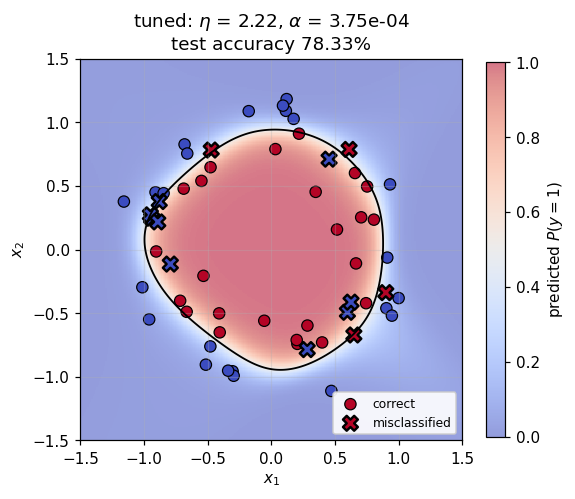

In [18]:
fig, ax = plt.subplots(figsize=(5.6, 5.2))
pcm = decision_panel(
    ax, net_bo,
    f"tuned: $\\eta$ = {lr_bo:.3g}, $\\alpha$ = {al_bo:.2e}\n"
    f"test accuracy {r_bo['test_acc']:.2%}")
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
fig.colorbar(pcm, ax=ax, shrink=0.85, label="predicted $P(y=1)$")
save(fig, "p1_2_tuned_classification.png")
plt.show()

**Figure 3.** The test data classified by the model at the hyperparameters selected by
Bayesian optimization, drawn on the same axes as Figure 1.

# Problem 2: Taxi demand forecasting (25 points)

The task is to forecast **pickup and drop-off demand over the next four time
steps**. The grid is 15 minutes, so the horizon is $4\times15\ \text{min} = 1$ hour.

Because the ten locations move together (measured below) and pickups and drop-offs
within a location are correlated, the problem is treated as one **system-wide
multivariate** forecast rather than twenty independent series: a single model reads
all 20 demand channels and predicts all 20 channels for each of the four future
steps.

## 2.1 Cleansing, Dataset class, and the split (5 points)

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

STUDY_START, STUDY_END = pd.Timestamp("2023-05-01"), pd.Timestamp("2023-11-01")
TRAIN_END, VAL_END = pd.Timestamp("2023-09-01"), pd.Timestamp("2023-10-01")
HORIZON = 4                     # 4 x 15 min = 1 hour ahead
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Disabling cuDNN autotuning removes run-to-run variation in algorithm choice.
# It is not sufficient for full determinism: Conv1d backward on CUDA accumulates
# with atomics whose ordering varies, so the CNN reproduces only to about 3e-2 in
# validation MAE, while the MLP and LSTM (no convolution) reproduce exactly.
# cudnn.deterministic=True was measured and rejected - the deterministic dilated
# Conv1d path did not complete two trainings in 90 minutes. The consequence is
# recorded with the lookback results; it affects neither the selected model nor
# any test figure.
torch.backends.cudnn.benchmark = False
print(f"torch {torch.__version__} on {DEVICE}, "
      f"cudnn.benchmark={torch.backends.cudnn.benchmark}")

raw = pd.read_csv(find_data("nyc-yellow-may2oct.csv"), parse_dates=["datetime"])
in_period = (raw.datetime >= STUDY_START) & (raw.datetime < STUDY_END)
taxi = raw[in_period].copy()

clean_audit = pd.DataFrame([
    ("raw file as supplied", len(raw)),
    ("excluded: timestamp outside the May-October 2023 study period", int((~in_period).sum())),
    ("retained: inside the study period", len(taxi)),
    ("excluded: duplicate (datetime, location_id) keys",
     int(taxi.duplicated(subset=["datetime", "location_id"]).sum())),
    ("excluded: negative, non-integer or infinite demand",
     int((taxi[["pickup_demand", "dropoff_demand"]].dropna() < 0).sum().sum())),
    ("excluded: extreme demand values (peak-hour demand, retained by design)", 0),
], columns=["step", "rows"])
clean_audit.to_csv(RES_DIR / "p2_1_cleaning_audit.csv", index=False)
print(clean_audit.to_string(index=False))
record("2.1", "n_raw", len(raw), "rows in the supplied CSV")
record("2.1", "n_excluded_outside_period", int((~in_period).sum()), "")
record("2.1", "n_retained", len(taxi), "")

torch 2.7.1+cu118 on cuda, cudnn.benchmark=False


                                                                  step   rows
                                                  raw file as supplied 176719
         excluded: timestamp outside the May-October 2023 study period     79
                                     retained: inside the study period 176640
                      excluded: duplicate (datetime, location_id) keys      0
                    excluded: negative, non-integer or infinite demand      0
excluded: extreme demand values (peak-hour demand, retained by design)      0


176640

Extreme values are **not** treated as outliers. The largest pickup counts occur on
weekday evenings, which is genuine peak demand and precisely the signal a
fleet-management forecast has to capture.

### Timestamp completeness and demand missingness are different defects

A row can exist while its demand columns are `NaN`. The two are audited separately.

In [20]:
GRID = pd.date_range(STUDY_START, STUDY_END, freq="15min", inclusive="left")
LOCS = sorted(taxi.location_id.unique())
n_days = (STUDY_END - STUDY_START).days
print(f"{n_days} days x 96 slots = {n_days * 96};  len(GRID) = {len(GRID)}")
assert len(GRID) == n_days * 96

defects = sum(len(set(GRID) ^ set(taxi.loc[taxi.location_id == L, "datetime"]))
              for L in LOCS)
print(f"symmetric difference between expected and observed timestamps, "
      f"summed over all {len(LOCS)} locations: {defects}")
assert defects == 0

DEMAND = np.stack([taxi.pivot(index="datetime", columns="location_id",
                              values=c).reindex(GRID)[LOCS].to_numpy(float)
                   for c in ("pickup_demand", "dropoff_demand")], axis=2)
OBSERVED = ~np.isnan(DEMAND)
print(f"\ndemand tensor {DEMAND.shape} = (time, location, [pickup, dropoff])")
print(f"observed {OBSERVED.sum():,} / {OBSERVED.size:,} = {OBSERVED.mean():.4%}")
print(f"missing  {(~OBSERVED).sum():,} ({(~OBSERVED).mean():.4%})")
record("2.1", "n_timesteps", len(GRID), "15-min slots, May-Oct 2023")
record("2.1", "n_locations", len(LOCS), "")
record("2.1", "n_demand_entries", int(DEMAND.size), "time x location x channel")
record("2.1", "n_missing_demand", int((~OBSERVED).sum()), "row exists, value NaN")
record("2.1", "pct_observed", float(OBSERVED.mean()), "")

184 days x 96 slots = 17664;  len(GRID) = 17664


symmetric difference between expected and observed timestamps, summed over all 10 locations: 0

demand tensor (17664, 10, 2) = (time, location, [pickup, dropoff])
observed 347,466 / 353,280 = 98.3543%
missing  5,814 (1.6457%)


0.9835427989130435

### Dependence structure

These measurements decide two modelling choices: whether the ten locations should
share one model, and whether a random split would be admissible.

In [21]:
_wide_p = pd.DataFrame(DEMAND[:, :, 0], index=GRID, columns=LOCS)
_wide_d = pd.DataFrame(DEMAND[:, :, 1], index=GRID, columns=LOCS)

_cp = _wide_p.corr().to_numpy()
_off = _cp[~np.eye(len(LOCS), dtype=bool)]
_pd_pairs = [_wide_p[L].corr(_wide_d[L]) for L in LOCS]
print(f"cross-location correlation of pickups : mean {_off.mean():.3f} "
      f"(range {_off.min():.3f} to {_off.max():.3f})")
print(f"pickup-dropoff correlation per location: mean {np.mean(_pd_pairs):.3f} "
      f"(range {min(_pd_pairs):.3f} to {max(_pd_pairs):.3f})")

_s = _wide_p[LOCS[0]].interpolate()
_ac = {lag: _s.autocorr(lag) for lag in (1, 4, 96, 672)}
for lag, lbl in ((1, "15 min"), (4, "1 h"), (96, "1 day"), (672, "1 week")):
    print(f"autocorrelation at lag {lag:3d} ({lbl:6s}): {_ac[lag]:.3f}")

def cross_location_mean(channel=0):
    """Mean over the locations observed at each step.

    One timestamp has no observed location at all, so a plain nanmean would
    average an empty slice; dividing explicitly leaves that step as NaN without
    relying on warning behaviour.
    """
    seen = OBSERVED[:, :, channel].sum(axis=1)
    total = np.where(OBSERVED, DEMAND, 0.0)[:, :, channel].sum(axis=1)
    return np.divide(total, seen, out=np.full(len(GRID), np.nan), where=seen > 0)


_step_mean_pickup = cross_location_mean(0)
print(f"timesteps with no observed location at all: "
      f"{int(np.isnan(_step_mean_pickup).sum())}")
_monthly = (pd.DataFrame({"t": GRID, "p": _step_mean_pickup})
            .set_index("t").resample("MS").mean())
print("\nmonthly mean pickup demand (the chronological split spans a level shift):")
print(_monthly.round(2).to_string())
_monthly.to_csv(RES_DIR / "p2_1_monthly_mean.csv")

record("2.1", "xloc_pickup_corr", float(_off.mean()), "mean pairwise, off-diagonal")
record("2.1", "pickup_dropoff_corr", float(np.mean(_pd_pairs)), "mean within location")
record("2.1", "autocorr_lag1", float(_ac[1]), "15 min")
record("2.1", "autocorr_lag96", float(_ac[96]), "1 day")
record("2.1", "autocorr_lag672", float(_ac[672]), "1 week")
record("2.1", "train_mean_pickup",
    float(np.nanmean(np.where(OBSERVED, DEMAND, np.nan)[GRID < TRAIN_END][:, :, 0])),
    "May-August")
record("2.1", "test_mean_pickup",
    float(np.nanmean(np.where(OBSERVED, DEMAND, np.nan)[GRID >= VAL_END][:, :, 0])),
    "October")

cross-location correlation of pickups : mean 0.683 (range 0.355 to 0.902)
pickup-dropoff correlation per location: mean 0.704 (range 0.312 to 0.945)
autocorrelation at lag   1 (15 min): 0.915
autocorrelation at lag   4 (1 h   ): 0.788
autocorrelation at lag  96 (1 day ): 0.826
autocorrelation at lag 672 (1 week): 0.769
timesteps with no observed location at all: 1

monthly mean pickup demand (the chronological split spans a level shift):
                p
t                
2023-05-01  46.11
2023-06-01  44.65
2023-07-01  38.05
2023-08-01  36.95
2023-09-01  37.95
2023-10-01  45.85


46.418336058871624

### Why individual entries are masked rather than whole windows dropped

Per-channel missingness is only 1.65%, but a multivariate window needs all 20
channels at every step, so the rates compound. The table below shows how quickly
window-dropping becomes unusable as the lookback grows, and why masking individual
target entries is the only rule that keeps the data while still never training or
scoring against an imputed value.

In [22]:
any_missing = (~OBSERVED).any(axis=(1, 2))
rows = []
for L in (12, 24, 48, 96):
    n = len(GRID) - L - HORIZON + 1
    tgt_bad = np.array([any_missing[i + L:i + L + HORIZON].any() for i in range(n)])
    inp_bad = np.array([any_missing[i:i + L].any() for i in range(n)])
    rows.append({"lookback": L, "windows": n,
                 "keep_if_target_complete": (~tgt_bad).mean(),
                 "keep_if_input_and_target_complete": (~(tgt_bad | inp_bad)).mean()})
drop_tbl = pd.DataFrame(rows)
drop_tbl.to_csv(RES_DIR / "p2_1_window_dropping.csv", index=False)
print(f"timesteps with at least one of 20 channels missing: "
      f"{any_missing.mean():.2%}\n")
print(drop_tbl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nmasking individual target entries instead costs "
      f"{(~OBSERVED).mean():.4%} of supervision")
record("2.1", "pct_timesteps_any_channel_missing", float(any_missing.mean()), "")

timesteps with at least one of 20 channels missing: 9.86%

 lookback  windows  keep_if_target_complete  keep_if_input_and_target_complete
       12    17649                   0.8339                             0.7033
       24    17637                   0.8343                             0.5820
       48    17613                   0.8340                             0.3397
       96    17565                   0.8336                             0.0105

masking individual target entries instead costs 1.6457% of supervision


0.09861865942028986

### Causal fill, training-only scaling, cyclical calendar terms

Inputs are filled by **forward fill**, which copies from an earlier timestamp only.
Bidirectional interpolation is rejected: it would use observations later than the
timestamp being filled, which would not exist at forecast time. Because forward fill
propagates strictly past→future, it also cannot move a value from a later partition
into an earlier one.

Standardisation is per **location × channel**, giving 20 mean/standard-deviation
pairs, because channel means span roughly $14$ to $60$ trips per 15 min, so a single global
statistic would leave channels badly scaled. Both statistics come from May–August
only.

In [23]:
FILLED = DEMAND.copy()
for j in range(len(LOCS)):
    for k in range(2):
        FILLED[:, j, k] = pd.Series(FILLED[:, j, k]).ffill().to_numpy()
assert not np.isnan(FILLED).any(), "a channel is missing at the very first step"

is_train_step = GRID < TRAIN_END
MU = np.nanmean(np.where(OBSERVED, DEMAND, np.nan)[is_train_step], axis=0)
SD = np.nanstd(np.where(OBSERVED, DEMAND, np.nan)[is_train_step], axis=0)
assert (SD > 0).all()

tod = GRID.hour * 4 + GRID.minute // 15
CALENDAR = np.stack([
    np.sin(2 * np.pi * tod / 96), np.cos(2 * np.pi * tod / 96),
    np.sin(2 * np.pi * GRID.dayofweek / 7),
    np.cos(2 * np.pi * GRID.dayofweek / 7)], axis=1)

# One (T, 44) feature matrix, built once so __getitem__ only has to slice.
#   cols  0..19  standardised demand, index = location*2 + channel
#   cols 20..39  imputation flags, same order
#   cols 40..43  sin/cos time-of-day, sin/cos day-of-week
FEAT = np.concatenate([
    ((FILLED - MU) / SD).reshape(len(GRID), -1),
    (~OBSERVED).astype(float).reshape(len(GRID), -1),
    CALENDAR], axis=1).astype(np.float32)
TARGET = np.where(OBSERVED, (DEMAND - MU) / SD, 0.0).astype(np.float32)
MASK = OBSERVED.astype(np.float32)

zt = np.where(OBSERVED, (DEMAND - MU) / SD, np.nan)
print(f"standardised demand, train: mean {np.nanmean(zt[is_train_step]):+.2e}, "
      f"sd {np.nanstd(zt[is_train_step]):.6f}")
for name, sel in (("val", (GRID >= TRAIN_END) & (GRID < VAL_END)),
                  ("test", GRID >= VAL_END)):
    print(f"same transform on {name:4s}: mean {np.nanmean(zt[sel]):+.4f}, "
          f"sd {np.nanstd(zt[sel]):.4f}")
print("(val and test are deliberately not 0/1 - that would indicate leakage)")
record("2.1", "n_features", FEAT.shape[1], "20 demand + 20 flags + 4 calendar")

standardised demand, train: mean +0.00e+00, sd 1.000000
same transform on val : mean -0.0822, sd 1.0569
same transform on test: mean +0.1555, sd 1.0825
(val and test are deliberately not 0/1 - that would indicate leakage)


44

### The Dataset class

In [24]:
class TaxiDemandDataset(Dataset):
    """Sliding windows over the 15-min demand grid.

    All arrays are supplied through __init__ and windowing is index arithmetic,
    so __getitem__ only slices; no preprocessing is hidden inside it.

    x : (lookback, 44)            time x features, column order documented above
    y : (horizon, n_loc, 2)       standardised demand
    m : (horizon, n_loc, 2)       1.0 where the target was genuinely observed
    """

    def __init__(self, feat, target, mask, grid, starts, lookback,
                 horizon=HORIZON):
        self.feat, self.target, self.mask, self.grid = feat, target, mask, grid
        self.starts = np.asarray(starts, dtype=np.int64)
        self.lookback, self.horizon = lookback, horizon

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, i):
        s = int(self.starts[i])
        a, b = s + self.lookback, s + self.lookback + self.horizon
        return (torch.from_numpy(self.feat[s:a]),
                torch.from_numpy(self.target[a:b]),
                torch.from_numpy(self.mask[a:b]))

    def input_times(self, i):
        s = int(self.starts[i])
        return self.grid[s:s + self.lookback]

    def target_times(self, i):
        a = int(self.starts[i]) + self.lookback
        return self.grid[a:a + self.horizon]

    def target_index(self):
        """(n_samples, horizon) absolute time indices of the target steps."""
        return (self.starts[:, None] + self.lookback
                + np.arange(self.horizon)[None, :])


def make_splits(lookback, horizon=HORIZON):
    """Chronological split. A sample belongs to the partition containing its
    entire target horizon, so no target can straddle a boundary. Input windows
    may reach back into the previous partition, which is what an operator
    genuinely has available at forecast time."""
    n = len(GRID) - lookback - horizon + 1
    starts = np.arange(n)
    t_first = GRID[starts + lookback]
    t_last = GRID[starts + lookback + horizon - 1]
    sel = {"train": (t_first >= STUDY_START) & (t_last < TRAIN_END),
           "val": (t_first >= TRAIN_END) & (t_last < VAL_END),
           "test": (t_first >= VAL_END) & (t_last < STUDY_END)}
    ds = {k: TaxiDemandDataset(FEAT, TARGET, MASK, GRID, starts[m], lookback,
                               horizon) for k, m in sel.items()}
    return ds, int(n - sum(m.sum() for m in sel.values()))

In [25]:
LOOKBACK = 24          # 6 hours; chosen by the sensitivity analysis in 2.2
DS, n_straddling = make_splits(LOOKBACK)

split_tbl = pd.DataFrame([{
    "partition": k,
    "first target": str(DS[k].target_times(0)[0]),
    "last target": str(DS[k].target_times(len(DS[k]) - 1)[-1]),
    "samples": len(DS[k])} for k in ("train", "val", "test")])
split_tbl.to_csv(RES_DIR / "p2_1_split.csv", index=False)
print(split_tbl.to_string(index=False))
print(f"\nboundary-straddling windows dropped: {n_straddling}")
for k in DS:
    record("2.1", f"n_{k}", len(DS[k]), "forecasting windows")
record("2.1", "n_straddling_dropped", n_straddling, "")
record("2.1", "lookback", LOOKBACK, f"15-min steps = {LOOKBACK / 4:g} hours")
record("2.1", "horizon", HORIZON, "15-min steps = 1 hour")

partition        first target         last target  samples
    train 2023-05-01 06:00:00 2023-08-31 23:45:00    11781
      val 2023-09-01 00:00:00 2023-09-30 23:45:00     2877
     test 2023-10-01 00:00:00 2023-10-31 23:45:00     2973

boundary-straddling windows dropped: 6


4

### Verification

In [26]:
x, y, m = DS["train"][0]
print(f"x {tuple(x.shape)} {x.dtype}  = (lookback, 20 demand + 20 flags + 4 cal)")
print(f"y {tuple(y.shape)} {y.dtype}  = (horizon, location, [pickup, dropoff])")
print(f"m {tuple(m.shape)} {m.dtype}\n")

TI = {k: DS[k].target_index() for k in DS}
checks = [
    ("train targets end before val targets begin",
     TI["train"].max() < TI["val"].min()),
    ("val targets end before test targets begin",
     TI["val"].max() < TI["test"].min()),
    ("target timestamps disjoint across all three partitions",
     not (set(TI["train"].ravel()) & set(TI["val"].ravel()))
     and not (set(TI["val"].ravel()) & set(TI["test"].ravel()))
     and not (set(TI["train"].ravel()) & set(TI["test"].ravel()))),
]
for k in DS:
    checks.append((f"{k}: last input step precedes the first target step",
                   bool((DS[k].starts + LOOKBACK - 1 < TI[k][:, 0]).all())))
    checks.append((f"{k}: target horizon contiguous, length {HORIZON}",
                   bool((np.diff(TI[k], axis=1) == 1).all()
                        and TI[k].shape[1] == HORIZON)))
checks.append(("standardisation fitted on training rows only",
               np.allclose(MU, np.nanmean(np.where(OBSERVED, DEMAND, np.nan)
                                          [GRID < TRAIN_END], axis=0))))
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
assert all(ok for _, ok in checks), "a leakage check failed"
record("2.1", "n_leakage_checks_passed", len(checks), "all assertions")

x (24, 44) torch.float32  = (lookback, 20 demand + 20 flags + 4 cal)
y (4, 10, 2) torch.float32  = (horizon, location, [pickup, dropoff])
m (4, 10, 2) torch.float32

  [PASS] train targets end before val targets begin
  [PASS] val targets end before test targets begin
  [PASS] target timestamps disjoint across all three partitions
  [PASS] train: last input step precedes the first target step
  [PASS] train: target horizon contiguous, length 4
  [PASS] val: last input step precedes the first target step
  [PASS] val: target horizon contiguous, length 4
  [PASS] test: last input step precedes the first target step
  [PASS] test: target horizon contiguous, length 4
  [PASS] standardisation fitted on training rows only


10

In [27]:
# Trace one Dataset item back to the source dataframe.
k, i = "val", 500
xs, ys, ms = DS[k][i]
it, tt = DS[k].input_times(i), DS[k].target_times(i)
print(f"{k} sample {i}")
print(f"  inputs  {it[0]} .. {it[-1]}  ({len(it)} steps)")
print(f"  targets {tt[0]} .. {tt[-1]}  ({len(tt)} steps)")

loc0 = LOCS[0]
src = taxi[(taxi.location_id == loc0)
           & (taxi.datetime.isin(tt))].sort_values("datetime")
recon = ys[:, 0, 0].numpy() * SD[0, 0] + MU[0, 0]
print(f"\n  location {loc0} pickup from the CSV : "
      f"{src.pickup_demand.to_numpy()}")
print(f"  de-standardised y[:, 0, 0]         : {np.round(recon, 4)}")
print(f"  mask m[:, 0, 0]                    : {ms[:, 0, 0].numpy()}")
assert np.allclose(recon[ms[:, 0, 0].numpy() == 1],
                   src.pickup_demand.dropna().to_numpy())

last_val = taxi[(taxi.location_id == loc0)
                & (taxi.datetime == it[-1])].pickup_demand.iloc[0]
print(f"\n  last input step {it[-1]}, location {loc0} pickup: {last_val}")
print(f"  de-standardised x[-1, 0]           : "
      f"{xs[-1, 0].item() * SD[0, 0] + MU[0, 0]:.4f}")
print(f"  imputation flag x[-1, 20]          : {xs[-1, 20].item()}")
print("\n  [PASS] Dataset output matches the source rows")

val sample 500
  inputs  2023-09-05 23:00:00 .. 2023-09-06 04:45:00  (24 steps)
  targets 2023-09-06 05:00:00 .. 2023-09-06 05:45:00  (4 steps)

  location 132 pickup from the CSV : [10. 27. 31. 26.]
  de-standardised y[:, 0, 0]         : [10. 27. 31. 26.]
  mask m[:, 0, 0]                    : [1. 1. 1. 1.]

  last input step 2023-09-06 04:45:00, location 132 pickup: 17.0
  de-standardised x[-1, 0]           : 17.0000
  imputation flag x[-1, 20]          : 0.0

  [PASS] Dataset output matches the source rows


## 2.2 Architecture, training and evaluation (15 points)

### Metrics

All metrics are computed over observed target entries only, in trips per 15 min:

$$\text{MAE}=\frac{\sum_i m_i|\hat y_i-y_i|}{\sum_i m_i},\qquad
\text{RMSE}=\sqrt{\frac{\sum_i m_i(\hat y_i-y_i)^2}{\sum_i m_i}},\qquad
\text{bias}=\frac{\sum_i m_i(\hat y_i-y_i)}{\sum_i m_i}.$$

Squared errors are accumulated globally before the square root; averaging per-batch
RMSEs would give a different and incorrect number. The training loss is the same
masked mean squared error, computed on standardised targets. MAPE is not reported:
5,836 pickup targets are exactly zero, which makes it undefined.

In [28]:
def masked_metrics(pred, true, mask):
    """MAE, RMSE and bias over observed entries only, in the units of `pred`."""
    err = (pred - true) * mask
    n = mask.sum()
    return {"mae": float(np.abs(err).sum() / n),
            "rmse": float(np.sqrt((err ** 2).sum() / n)),
            "bias": float(err.sum() / n), "n": int(n)}


def per_horizon(pred, true, mask):
    return [masked_metrics(pred[:, h], true[:, h], mask[:, h])
            for h in range(pred.shape[1])]


def masked_mse_loss(pred, true, mask):
    return ((pred - true) ** 2 * mask).sum() / mask.sum()


def to_original(z):
    return z * SD + MU


# Verification on a hand-computable example: errors 2, 3, 6 on three observed
# entries; the fourth is masked and must not influence anything.
_p = np.array([[3.0, 5.0], [10.0, 0.0]])
_t = np.array([[1.0, 2.0], [4.0, 99.0]])
_m = np.array([[1.0, 1.0], [1.0, 0.0]])
_g = masked_metrics(_p, _t, _m)
print(f"by hand : MAE {(2 + 3 + 6) / 3:.6f}  RMSE {np.sqrt((4 + 9 + 36) / 3):.6f}  n 3")
print(f"function: MAE {_g['mae']:.6f}  RMSE {_g['rmse']:.6f}  n {_g['n']}")
assert abs(_g["mae"] - 11 / 3) < 1e-12 and abs(_g["rmse"] - np.sqrt(49 / 3)) < 1e-12
_l = masked_mse_loss(torch.tensor(_p), torch.tensor(_t), torch.tensor(_m)).item()
_p2 = _p.copy(); _p2[1, 1] = -1e6
_l2 = masked_mse_loss(torch.tensor(_p2), torch.tensor(_t), torch.tensor(_m)).item()
print(f"masked MSE {_l:.6f} (by hand {49 / 3:.6f}); setting the masked prediction "
      f"to -1e6 gives {_l2:.6f}")
assert abs(_l - 49 / 3) < 1e-12 and abs(_l2 - 49 / 3) < 1e-9
print("[PASS] masked metrics and loss")

by hand : MAE 3.666667  RMSE 4.041452  n 3
function: MAE 3.666667  RMSE 4.041452  n 3
masked MSE 16.333333 (by hand 16.333333); setting the masked prediction to -1e6 gives 16.333333
[PASS] masked metrics and loss


### Baselines

Three baselines are evaluated on exactly the same targets and mask as the networks.
They also supply the evidence for the discussion in 2.3.

In [29]:
WEEK = 672                                  # 7 days x 96 slots
DOW = GRID.dayofweek.to_numpy()
TOD = (GRID.hour * 4 + GRID.minute // 15).to_numpy()

# Historical Average fitted on the training period only:
# location x channel x weekday x 15-min slot.
_tr = np.where(GRID < TRAIN_END)[0]
_sum = np.zeros((7, 96, len(LOCS), 2))
_cnt = np.zeros((7, 96, len(LOCS), 2))
np.add.at(_sum, (DOW[_tr], TOD[_tr]), np.where(OBSERVED[_tr], DEMAND[_tr], 0.0))
np.add.at(_cnt, (DOW[_tr], TOD[_tr]), OBSERVED[_tr].astype(float))
HIST_AVG = np.divide(_sum, _cnt, out=np.zeros_like(_sum), where=_cnt > 0)
print(f"Historical Average table {HIST_AVG.shape}; empty cells {(_cnt == 0).sum()}; "
      f"median observations per cell {np.median(_cnt):.0f}")


def baseline_predictions(ds):
    tix = ds.target_index()
    last = ds.starts + ds.lookback - 1
    return {
        "Persistence": np.repeat(FILLED[last][:, None], HORIZON, axis=1),
        "Seasonal naive (t-1 week)": FILLED[tix - WEEK],
        "Historical Average": HIST_AVG[DOW[tix], TOD[tix]],
    }


def evaluate_baselines(ds):
    tix = ds.target_index()
    true = np.nan_to_num(DEMAND[tix])
    msk = OBSERVED[tix].astype(float)
    rows = []
    for name, pred in baseline_predictions(ds).items():
        met = masked_metrics(pred, true, msk)
        hz = per_horizon(pred, true, msk)
        rows.append({"model": name, "MAE": met["mae"], "RMSE": met["rmse"],
                     "bias": met["bias"],
                     **{f"+{15 * (i + 1)}": h["mae"] for i, h in enumerate(hz)}})
    return pd.DataFrame(rows)


val_base = evaluate_baselines(DS["val"])
print()
print(val_base.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
for _, r in val_base.iterrows():
    key = r["model"].split()[0].lower()
    record("2.2", f"val_{key}_mae", r["MAE"], "baseline, validation")
    record("2.2", f"val_{key}_rmse", r["RMSE"], "baseline, validation")

# independent NumPy reproduction of one baseline metric
_tix = DS["val"].target_index()
_ok = OBSERVED[_tix]
_hp = HIST_AVG[DOW[_tix], TOD[_tix]]
print(f"\nindependent check, Historical Average: "
      f"MAE {np.abs(_hp[_ok] - DEMAND[_tix][_ok]).mean():.6f} vs "
      f"{val_base.loc[2, 'MAE']:.6f}")

Historical Average table (7, 96, 10, 2); empty cells 0; median observations per cell 18

                    model     MAE    RMSE    bias     +15     +30     +45     +60
              Persistence  8.6235 13.1995 -0.0246  7.0104  8.1957  9.1973 10.0906
Seasonal naive (t-1 week) 16.6650 26.5186 -1.4551 16.6493 16.6602 16.6705 16.6801
       Historical Average 11.2659 18.3915  2.1890 11.2643 11.2654 11.2666 11.2674



independent check, Historical Average: MAE 11.265914 vs 11.265914


### Models

Three architectures. Their parameter counts are not matched: at the lookback selected
below the MLP is the largest of the three, because flattening makes its input layer
grow with the lookback while the CNN and the LSTM share parameters across time. That
works against the conclusion rather than for it: the MLP has the most capacity and
still loses, so the comparison reflects inductive bias rather than capacity.

* **MLP**: flattens the window. Can model arbitrary interactions across all lags and
  channels, but has no explicit temporal structure.
* **1-D CNN**: convolves along time with dilations 1, 2, 4 and kernel 3, giving a
  receptive field of $1+2(1+2+4)=15$ steps. Weights are shared across time and
  computation is parallel. The head concatenates the last time step with a mean over
  time, so its size does not depend on the lookback.
* **LSTM**: one recurrent layer, maintaining state along the sequence. Sequential
  and therefore slower, but the state can carry information that a fixed receptive
  field cannot.

Which is most suitable is decided by validation MAE, not by assertion.

In [30]:
class MLPForecaster(nn.Module):
    def __init__(self, lookback, n_feat, n_out, hidden=(128, 64), p=0.1):
        super().__init__()
        dims = [lookback * n_feat, *hidden]
        layers = []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU(), nn.Dropout(p)]
        self.net = nn.Sequential(*layers, nn.Linear(dims[-1], n_out))

    def forward(self, x):
        return self.net(x.flatten(1))


class CNNForecaster(nn.Module):
    def __init__(self, n_feat, n_out, ch=96, k=3, dilations=(1, 2, 4), p=0.1):
        super().__init__()
        blocks, c_in = [], n_feat
        for d in dilations:
            blocks += [nn.Conv1d(c_in, ch, k, padding=d * (k - 1) // 2,
                                 dilation=d), nn.ReLU(), nn.Dropout(p)]
            c_in = ch
        self.conv = nn.Sequential(*blocks)
        self.head = nn.Linear(2 * ch, n_out)
        self.receptive_field = 1 + sum((k - 1) * d for d in dilations)

    def forward(self, x):
        h = self.conv(x.transpose(1, 2))          # Conv1d wants (B, C, T)
        return self.head(torch.cat([h[:, :, -1], h.mean(dim=2)], dim=1))


class LSTMForecaster(nn.Module):
    def __init__(self, n_feat, n_out, hidden=128, p=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=1, batch_first=True)
        self.drop = nn.Dropout(p)
        self.head = nn.Linear(hidden, n_out)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(self.drop(out[:, -1]))


N_FEAT = FEAT.shape[1]
OUT_SHAPE = (HORIZON, len(LOCS), 2)
N_OUT = int(np.prod(OUT_SHAPE))


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


def build(name, lookback=None, seed=RANDOM_STATE):
    """Construct a model with reproducible weights.

    The seed is set HERE, before the layers are created. Seeding inside the
    training loop instead would leave initialisation at the mercy of whatever
    RNG state earlier cells happened to leave behind, so the same nominal seed
    would give different weights depending on execution history.
    """
    torch.manual_seed(seed)
    lookback = LOOKBACK if lookback is None else lookback
    if name == "MLP":
        return MLPForecaster(lookback, N_FEAT, N_OUT)
    if name == "1-D CNN":
        return CNNForecaster(N_FEAT, N_OUT)
    return LSTMForecaster(N_FEAT, N_OUT)


# parameter counts checked against the closed-form n_in*n_out + n_out per layer
_c = CNNForecaster(N_FEAT, N_OUT)
checks = {
    "MLP": (MLPForecaster(LOOKBACK, N_FEAT, N_OUT),
            (LOOKBACK * N_FEAT) * 128 + 128 + 128 * 64 + 64 + 64 * N_OUT + N_OUT),
    "1-D CNN": (_c, (N_FEAT * 96 * 3 + 96) + 2 * (96 * 96 * 3 + 96)
                + (2 * 96 * N_OUT + N_OUT)),
    "LSTM": (LSTMForecaster(N_FEAT, N_OUT),
             4 * (N_FEAT * 128 + 128 * 128 + 2 * 128) + 128 * N_OUT + N_OUT),
}
for nm, (mod, hand) in checks.items():
    got = count_params(mod)
    print(f"{nm:>9}: formula {hand:>7} vs PyTorch {got:>7}  "
          f"{'OK' if hand == got else 'MISMATCH'}")
    assert hand == got
print(f"CNN receptive field: {_c.receptive_field} steps "
      f"({_c.receptive_field * 15} min)")

      MLP: formula  148752 vs PyTorch  148752  OK
  1-D CNN: formula   83696 vs PyTorch   83696  OK
     LSTM: formula   99408 vs PyTorch   99408  OK
CNN receptive field: 15 steps (225 min)


In [31]:
import copy


@torch.no_grad()
def predict_split(model, ds):
    model.eval()
    dl = DataLoader(ds, batch_size=512, shuffle=False)
    P, Y, M = [], [], []
    for xb, yb, mb in dl:
        P.append(model(xb.to(DEVICE)).view(-1, *OUT_SHAPE).cpu())
        Y.append(yb); M.append(mb)
    return (torch.cat(P).numpy(), torch.cat(Y).numpy(), torch.cat(M).numpy())


def train_model(model, ds_train, ds_val, epochs=60, batch_size=64, lr=1e-3,
                patience=8, seed=RANDOM_STATE):
    """Masked-MSE training. Early stopping and checkpointing on validation loss;
    the best checkpoint is restored before any metric is reported."""
    torch.manual_seed(seed)
    model = model.to(DEVICE)
    dl_tr = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                       generator=torch.Generator().manual_seed(seed))
    dl_va = DataLoader(ds_val, batch_size=512, shuffle=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best = {"val_loss": np.inf, "epoch": -1, "state": None}
    hist, t0, bad = [], time.perf_counter(), 0
    for ep in range(1, epochs + 1):
        model.train()
        num = den = 0.0
        for xb, yb, mb in dl_tr:
            xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            loss = masked_mse_loss(model(xb).view_as(yb), yb, mb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            num += loss.item() * mb.sum().item()   # weight by observed count
            den += mb.sum().item()
        tr_loss = num / den

        model.eval()
        vnum = vden = 0.0
        with torch.no_grad():
            for xb, yb, mb in dl_va:
                xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
                p = model(xb).view_as(yb)
                vnum += ((p - yb) ** 2 * mb).sum().item()
                vden += mb.sum().item()
        va_loss = vnum / vden
        hist.append({"epoch": ep, "train_loss": tr_loss, "val_loss": va_loss})

        if va_loss < best["val_loss"] - 1e-6:
            best = {"val_loss": va_loss, "epoch": ep,
                    "state": copy.deepcopy(model.state_dict())}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best["state"])
    P, Y, M = predict_split(model, ds_val)
    met = masked_metrics(to_original(P), to_original(Y), M)
    return {"model": model, "history": pd.DataFrame(hist),
            "best_epoch": best["epoch"], "val_mae": met["mae"],
            "val_rmse": met["rmse"], "params": count_params(model),
            "seconds": time.perf_counter() - t0,
            "val_pred": to_original(P), "val_true": to_original(Y),
            "val_mask": M}

### How much history is useful? (validation only)

A ridge regression on the flattened window gives a cheap, fully deterministic first
look. It is not the final answer, for a reason that turns out to matter: flattening
means every extra step adds 44 more inputs, so the probe conflates "does older
demand carry signal" with "can a linear model afford the extra dimensions".

In [32]:
from sklearn.linear_model import Ridge

probe_rows = []
for L in (4, 8, 12, 24, 48, 96):
    ds_L, _ = make_splits(L)
    def design(d):
        s = d.starts
        X = np.stack([FEAT[a:a + L].ravel() for a in s])
        tix = d.target_index()
        return X, TARGET[tix].reshape(len(s), -1), MASK[tix].reshape(len(s), -1)
    Xtr, Ytr, Mtr = design(ds_L["train"])
    Xva, Yva, Mva = design(ds_L["val"])
    fit = Mtr.all(axis=1)                     # probe trains on complete targets
    # An SVD solve stays stable at the largest lookback, where the flattened
    # design matrix becomes badly conditioned (overlapping windows are highly
    # collinear) and the default solver warns.
    pv = Ridge(alpha=1.0, solver="svd").fit(Xtr[fit], Ytr[fit]).predict(Xva)
    scale = np.tile(SD.ravel(), HORIZON)
    err = (pv - Yva) * scale                  # difference of standardised values
    probe_rows.append({"lookback": L, "hours": L * .25, "in_dim": Xtr.shape[1],
                       "val_MAE": np.abs(err[Mva > 0]).mean(),
                       "val_RMSE": np.sqrt((err[Mva > 0] ** 2).mean())})
probe = pd.DataFrame(probe_rows)
probe.to_csv(RES_DIR / "p2_2_lookback_ridge.csv", index=False)
print("ridge probe (deterministic)")
print(probe.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

ridge probe (deterministic)
 lookback   hours  in_dim  val_MAE  val_RMSE
        4  1.0000     176   7.7328   11.2263
        8  2.0000     352   7.7534   11.3415
       12  3.0000     528   7.8801   11.7183
       24  6.0000    1056   8.5907   12.5876
       48 12.0000    2112   9.3051   14.0820
       96 24.0000    4224  10.4227   15.6490


The linear probe is minimised at the shortest window it was given, and degrades
steadily as the window grows. That is largely a statement about the probe itself: it
flattens the window, so each extra step adds 44 more inputs against a fixed number
of training samples, and overlapping windows are highly collinear. A model that
shares parameters across time pays no such penalty, so the lookback cannot be
settled on a flattened linear model alone.

### Architecture and lookback (validation only)

The two interact, so they are chosen in two passes. First the three architectures
are compared at a provisional lookback. The winner is then swept over lookback, and
finally all three are re-compared at the selected value to confirm the ranking still
holds. The selection criterion is fixed before any result is seen: **primary =
validation MAE**, secondary = validation RMSE. Every model receives identical
inputs, samples, mask, optimiser, batch size, epoch budget and early-stopping rule.

In [33]:
ARCHS = ["MLP", "1-D CNN", "LSTM"]
L_PROVISIONAL = 12


def compare_architectures(lookback, label):
    ds_L, _ = make_splits(lookback)
    out = {a: {RANDOM_STATE: train_model(build(a, lookback), ds_L["train"],
                                         ds_L["val"], seed=RANDOM_STATE)}
           for a in ARCHS}
    tab = pd.DataFrame([{
        "model": a, "lookback": lookback,
        "params": out[a][RANDOM_STATE]["params"],
        "best_epoch": out[a][RANDOM_STATE]["best_epoch"],
        "val_MAE": out[a][RANDOM_STATE]["val_mae"],
        "val_RMSE": out[a][RANDOM_STATE]["val_rmse"],
        "seconds": out[a][RANDOM_STATE]["seconds"]} for a in ARCHS])
    print(f"--- {label} (L = {lookback}) ---")
    print(tab.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    return out, tab


prov_runs, prov = compare_architectures(L_PROVISIONAL, "pass 1, provisional")
prov.to_csv(RES_DIR / "p2_2_comparison_provisional.csv", index=False)
PROV_BEST = prov.sort_values("val_MAE").model.iloc[0]
print(f"\nbest at the provisional lookback: {PROV_BEST}")
record("2.2", "provisional_lookback", L_PROVISIONAL, "pass 1")

--- pass 1, provisional (L = 12) ---
  model  lookback  params  best_epoch  val_MAE  val_RMSE  seconds
    MLP        12   81168           7   7.2334   10.7387  46.8538
1-D CNN        12   83696          10   7.3689   10.9114 211.0968
   LSTM        12   99408          10   6.8332   10.2762 197.3070

best at the provisional lookback: LSTM


12

#### Pass 2: lookback sweep for the winning architecture

In [34]:
look_rows = []
for L in (4, 12, 24, 48):
    ds_L, _ = make_splits(L)
    r = train_model(build(PROV_BEST, L), ds_L["train"], ds_L["val"])
    look_rows.append({"lookback": L, "hours": L * 0.25,
                      "n_train": len(ds_L["train"]), "params": r["params"],
                      "best_epoch": r["best_epoch"], "val_MAE": r["val_mae"],
                      "val_RMSE": r["val_rmse"], "seconds": r["seconds"]})
    print(f"L={L:3d} ({L * .25:4.1f} h)  val MAE {r['val_mae']:.4f}  "
          f"RMSE {r['val_rmse']:.4f}  best epoch {r['best_epoch']:2d}  "
          f"{r['seconds']:6.1f} s")
look = pd.DataFrame(look_rows)
look.to_csv(RES_DIR / "p2_2_lookback.csv", index=False)

BEST_L = int(look.loc[look.val_MAE.idxmin(), "lookback"])
runner = look.sort_values("val_MAE").iloc[1]
print(f"\n{PROV_BEST} lookback minimum at L = {BEST_L} "
      f"({look.val_MAE.min():.4f}); next best L = {int(runner.lookback)} "
      f"({runner.val_MAE:.4f}), a gap of {runner.val_MAE - look.val_MAE.min():.4f}")
print(f"the ridge probe preferred L = "
      f"{int(probe.loc[probe.val_MAE.idxmin(), 'lookback'])}: a recurrent model "
      f"benefits from sequence length that a flattened linear model is penalised for")
assert BEST_L == LOOKBACK, (
    f"the sweep selects L = {BEST_L} but LOOKBACK is set to {LOOKBACK}; "
    "update LOOKBACK in 2.1 and re-run so the pipeline matches the evidence")
record("2.2", "selected_lookback", BEST_L, f"{PROV_BEST} sweep minimum")
record("2.2", "lookback_gap_to_runner_up",
       float(runner.val_MAE - look.val_MAE.min()), "validation MAE")

L=  4 ( 1.0 h)  val MAE 6.9304  RMSE 10.3222  best epoch  8   129.3 s


L= 12 ( 3.0 h)  val MAE 6.8332  RMSE 10.2762  best epoch 10   196.9 s


L= 24 ( 6.0 h)  val MAE 6.6798  RMSE 10.1203  best epoch  9   266.7 s


L= 48 (12.0 h)  val MAE 6.7493  RMSE 10.1432  best epoch 16   594.3 s

LSTM lookback minimum at L = 24 (6.6798); next best L = 48 (6.7493), a gap of 0.0694
the ridge probe preferred L = 4: a recurrent model benefits from sequence length that a flattened linear model is penalised for


0.06944312324964841

#### Pass 3: re-compare all three architectures at the selected lookback

In [35]:
runs, comp = compare_architectures(LOOKBACK, "pass 3, final")
for a in ARCHS:
    k = a.replace(" ", "").replace("-", "").lower()
    record("2.2", f"val_{k}_mae", runs[a][RANDOM_STATE]["val_mae"], "validation")
    record("2.2", f"val_{k}_rmse", runs[a][RANDOM_STATE]["val_rmse"], "validation")
    record("2.2", f"{k}_params", runs[a][RANDOM_STATE]["params"], "")
final_best = comp.sort_values("val_MAE").model.iloc[0]
print(f"\nbest at L = {LOOKBACK}: {final_best}   "
      f"(ranking unchanged from pass 1: {final_best == PROV_BEST})")

--- pass 3, final (L = 24) ---
  model  lookback  params  best_epoch  val_MAE  val_RMSE  seconds
    MLP        24  148752          19   7.5072   10.9590 118.4032
1-D CNN        24   83696           3   7.9969   11.6808 141.0304
   LSTM        24   99408           9   6.6798   10.1203 266.3803

best at L = 24: LSTM   (ranking unchanged from pass 1: True)


In [36]:
# Seed stability for the top two, so the ranking is not read off initialisation noise
top2 = comp.sort_values("val_MAE").model.tolist()[:2]
for a in top2:
    for s in (RANDOM_STATE + 1, RANDOM_STATE + 2):
        # the seed must reach the constructor too, so initialisation varies
        runs[a][s] = train_model(build(a, seed=s), DS["train"], DS["val"], seed=s)

stab = pd.DataFrame([{
    "model": a, "seeds": len(runs[a]),
    "mean_val_MAE": np.mean([r["val_mae"] for r in runs[a].values()]),
    "sd_val_MAE": np.std([r["val_mae"] for r in runs[a].values()], ddof=1),
    "min": min(r["val_mae"] for r in runs[a].values()),
    "max": max(r["val_mae"] for r in runs[a].values())} for a in top2])
stab.to_csv(RES_DIR / "p2_2_seed_stability.csv", index=False)
print(stab.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

gap = stab.mean_val_MAE.iloc[1] - stab.mean_val_MAE.iloc[0]
pooled = np.sqrt((stab.sd_val_MAE ** 2).mean())
print(f"\ngap between the two means: {gap:.4f} trips/15min; pooled seed sd "
      f"{pooled:.4f}; ratio {gap / pooled:.1f}")
SELECTED = stab.sort_values("mean_val_MAE").model.iloc[0]
print(f"SELECTED ARCHITECTURE: {SELECTED}")
record("2.2", "seed_gap_top2", float(gap), "mean validation MAE difference")
record("2.2", "seed_pooled_sd", float(pooled), "")

model  seeds  mean_val_MAE  sd_val_MAE    min    max
 LSTM      3        6.7095      0.0390 6.6798 6.7536
  MLP      3        7.5536      0.0420 7.5072 7.5890

gap between the two means: 0.8441 trips/15min; pooled seed sd 0.0405; ratio 20.8
SELECTED ARCHITECTURE: LSTM


0.040514290638192535

In [37]:
# Combined comparison table. No test metric appears here by construction.
arch_tbl = pd.concat([
    val_base[["model", "MAE", "RMSE"]].rename(
        columns={"MAE": "val_MAE", "RMSE": "val_RMSE"}).assign(
        lookback="--", params="--", best_epoch="--"),
    comp[["model", "lookback", "params", "best_epoch", "val_MAE", "val_RMSE"]],
], ignore_index=True)[["model", "lookback", "params", "best_epoch",
                       "val_MAE", "val_RMSE"]]
arch_tbl.to_csv(RES_DIR / "p2_2_comparison.csv", index=False)
print(arch_tbl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\nper-horizon validation MAE")
for a in ARCHS:
    r = runs[a][RANDOM_STATE]
    hz = per_horizon(r["val_pred"], r["val_true"], r["val_mask"])
    print(f"  {a:>9} " + "  ".join(f"+{15 * (i + 1)}min {h['mae']:.4f}"
                                   for i, h in enumerate(hz)))

print("\nnegative predictions on validation (the output head is linear)")
for a in ARCHS:
    p = runs[a][RANDOM_STATE]["val_pred"]
    print(f"  {a:>9}: fraction < 0 {(p < 0).mean():.4%}, most negative {p.min():.3f}")

                    model lookback params best_epoch  val_MAE  val_RMSE
              Persistence       --     --         --   8.6235   13.1995
Seasonal naive (t-1 week)       --     --         --  16.6650   26.5186
       Historical Average       --     --         --  11.2659   18.3915
                      MLP       24 148752         19   7.5072   10.9590
                  1-D CNN       24  83696          3   7.9969   11.6808
                     LSTM       24  99408          9   6.6798   10.1203

per-horizon validation MAE
        MLP +15min 7.1372  +30min 7.3653  +45min 7.6025  +60min 7.9237
    1-D CNN +15min 7.5635  +30min 7.8760  +45min 8.1380  +60min 8.4099
       LSTM +15min 6.2665  +30min 6.6048  +45min 6.7997  +60min 7.0482

negative predictions on validation (the output head is linear)
        MLP: fraction < 0 2.4088%, most negative -9.987
    1-D CNN: fraction < 0 2.0994%, most negative -7.049
       LSTM: fraction < 0 3.2664%, most negative -5.913


### A recording outage in September

Inspecting the errors revealed a period where recorded demand collapses across
**all ten locations at once**. It is detected by a rule that no ordinary daily
cycle can trigger: a contiguous run of at least 24 hours whose cross-location mean
pickup stays below 5 trips per 15 min. The longest genuine overnight lull in six
months is 4 hours, so the separation is not a judgement call.

In [38]:
step_mean = cross_location_mean(0)          # NaN where nothing was observed
low = np.nan_to_num(step_mean, nan=0.0) < 5.0

low_runs, cur = [], []
for t in range(len(GRID)):
    if low[t]:
        cur.append(t)
    elif cur:
        low_runs.append(cur); cur = []
if cur:
    low_runs.append(cur)
low_runs.sort(key=len, reverse=True)
print("longest contiguous low runs (cross-location mean pickup < 5):")
for r in low_runs[:4]:
    print(f"  {GRID[r[0]]} .. {GRID[r[-1]]}  {len(r):4d} slots = {len(r) * .25:5.1f} h")

OUTAGE = np.zeros(len(GRID), bool)
for r in low_runs:
    if len(r) >= 96:                       # at least 24 h
        OUTAGE[r] = True
print(f"\noutage slots: {OUTAGE.sum()} ({OUTAGE.mean():.2%} of the series)")
for nm, a, b in (("train", STUDY_START, TRAIN_END), ("val", TRAIN_END, VAL_END),
                 ("test", VAL_END, STUDY_END)):
    m = (GRID >= a) & (GRID < b)
    print(f"  slots inside the outage in {nm:5s}: {int((OUTAGE & m).sum()):4d} "
          f"({(OUTAGE & m).sum() / m.sum():.2%} of that partition)")

_v = np.where(OBSERVED[OUTAGE], DEMAND[OUTAGE], np.nan)
print(f"\ninside the outage: missing rate {1 - OBSERVED[OUTAGE].mean():.2%} "
      f"(elsewhere {1 - OBSERVED[~OUTAGE].mean():.2%}), "
      f"mean of observed values {np.nanmean(_v):.3f}, "
      f"{np.nansum(_v == 0) / OBSERVED[OUTAGE].sum():.1%} exactly zero")
record("2.2", "outage_slots", int(OUTAGE.sum()), "contiguous >=24 h low run")
record("2.2", "outage_in_train", int((OUTAGE & (GRID < TRAIN_END)).sum()), "")
record("2.2", "outage_in_test", int((OUTAGE & (GRID >= VAL_END)).sum()), "")

longest contiguous low runs (cross-location mean pickup < 5):
  2023-09-21 13:15:00 .. 2023-09-24 23:45:00   331 slots =  82.8 h
  2023-05-03 01:30:00 .. 2023-05-03 05:15:00    16 slots =   4.0 h
  2023-05-09 01:30:00 .. 2023-05-09 05:15:00    16 slots =   4.0 h
  2023-07-04 02:15:00 .. 2023-07-04 06:00:00    16 slots =   4.0 h

outage slots: 331 (1.87% of the series)
  slots inside the outage in train:    0 (0.00% of that partition)
  slots inside the outage in val  :  331 (11.49% of that partition)
  slots inside the outage in test :    0 (0.00% of that partition)

inside the outage: missing rate 23.93% (elsewhere 1.22%), mean of observed values 1.640, 26.1% exactly zero


0

The event lies entirely inside September: the training and test partitions contain
none of it, so neither the fitted model nor the October evaluation is affected. Only
the validation figures are distorted. Repeating the comparison with those target
steps removed checks whether the architecture choice depended on them.

In [39]:
_clean = ~OUTAGE[TI["val"]]
print(f"validation target steps inside the outage: {(~_clean).sum():,} of "
      f"{_clean.size:,} ({(~_clean).mean():.2%})\n")
rob_rows = []
for a in ARCHS:
    rr = runs[a][RANDOM_STATE]
    keep = rr["val_mask"] * _clean[:, :, None, None]
    rob_rows.append({
        "model": a,
        "val_MAE_all": masked_metrics(rr["val_pred"], rr["val_true"],
                                      rr["val_mask"])["mae"],
        "val_MAE_outage_removed": masked_metrics(rr["val_pred"], rr["val_true"],
                                                 keep)["mae"]})
for nm, p in baseline_predictions(DS["val"]).items():
    _t = np.nan_to_num(DEMAND[TI["val"]])
    _m = OBSERVED[TI["val"]].astype(float)
    rob_rows.append({"model": nm,
                     "val_MAE_all": masked_metrics(p, _t, _m)["mae"],
                     "val_MAE_outage_removed": masked_metrics(
                         p, _t, _m * _clean[:, :, None, None])["mae"]})
rob = pd.DataFrame(rob_rows)
rob.to_csv(RES_DIR / "p2_2_outage_robustness.csv", index=False)
print(rob.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

_a = rob[rob.model.isin(ARCHS)]
print(f"\nbest by val_MAE_all            : {_a.loc[_a.val_MAE_all.idxmin(), 'model']}")
print(f"best by val_MAE_outage_removed : "
      f"{_a.loc[_a.val_MAE_outage_removed.idxmin(), 'model']}")

validation target steps inside the outage: 1,324 of 11,508 (11.51%)



                    model  val_MAE_all  val_MAE_outage_removed
                      MLP       7.5072                  7.2609
                  1-D CNN       7.9969                  7.5194
                     LSTM       6.6798                  6.8407
              Persistence       8.6235                  9.3256
Seasonal naive (t-1 week)      16.6650                 14.1147
       Historical Average      11.2659                  8.5368



best by val_MAE_all            : LSTM
best by val_MAE_outage_removed : LSTM


### Freezing the pipeline

Everything below is fixed **before** the test partition is evaluated.

In [40]:
best_run = min(runs[SELECTED].values(), key=lambda r: r["val_mae"])
sel_run = runs[SELECTED][RANDOM_STATE]        # reference-seed checkpoint

vp = sel_run["val_pred"]
raw_mae = masked_metrics(vp, sel_run["val_true"], sel_run["val_mask"])["mae"]
clip_mae = masked_metrics(np.clip(vp, 0, None), sel_run["val_true"],
                          sel_run["val_mask"])["mae"]
CLIP = clip_mae < raw_mae
print(f"validation MAE without clipping {raw_mae:.4f}, with clip(0, inf) "
      f"{clip_mae:.4f} -> clipping {'adopted' if CLIP else 'not adopted'}")

FROZEN = {
    "preprocessing": "study-period restriction; causal forward fill; per-channel "
                     "imputation flags; per location x channel standardisation "
                     "fitted on May-August; cyclical time-of-day and day-of-week",
    "lookback": LOOKBACK, "horizon": HORIZON,
    "architecture": SELECTED, "n_features": N_FEAT, "n_outputs": N_OUT,
    "parameters": sel_run["params"],
    "optimizer": "Adam", "learning_rate": 1e-3, "batch_size": 64,
    "max_epochs": 60,
    "early_stopping": "validation masked MSE, patience 8, best checkpoint restored",
    "best_epoch": sel_run["best_epoch"],
    "loss": "masked MSE on standardised targets",
    "postprocessing": "clip at 0" if CLIP else "none",
    "seed": RANDOM_STATE,
    "protocol": "A: validation-selected checkpoint trained on May-August only",
}
print("\n--- FINAL PIPELINE FROZEN ---")
for k, v in FROZEN.items():
    print(f"  {k:16s}: {v}")
pd.Series(FROZEN).to_csv(RES_DIR / "p2_2_frozen_pipeline.csv", header=False)
record("2.2", "selected_model_params", sel_run["params"], SELECTED)
record("2.2", "best_epoch", sel_run["best_epoch"], "early stopping on validation loss")
record("2.2", "val_selected_mae", sel_run["val_mae"], SELECTED)
record("2.2", "val_selected_rmse", sel_run["val_rmse"], SELECTED)

validation MAE without clipping 6.6798, with clip(0, inf) 6.6601 -> clipping adopted

--- FINAL PIPELINE FROZEN ---
  preprocessing   : study-period restriction; causal forward fill; per-channel imputation flags; per location x channel standardisation fitted on May-August; cyclical time-of-day and day-of-week
  lookback        : 24
  horizon         : 4
  architecture    : LSTM
  n_features      : 44
  n_outputs       : 80
  parameters      : 99408
  optimizer       : Adam
  learning_rate   : 0.001
  batch_size      : 64
  max_epochs      : 60
  early_stopping  : validation masked MSE, patience 8, best checkpoint restored
  best_epoch      : 9
  loss            : masked MSE on standardised targets
  postprocessing  : clip at 0
  seed            : 42
  protocol        : A: validation-selected checkpoint trained on May-August only


10.120292381979286

saved -> figures\p2_2_learning_curve.png


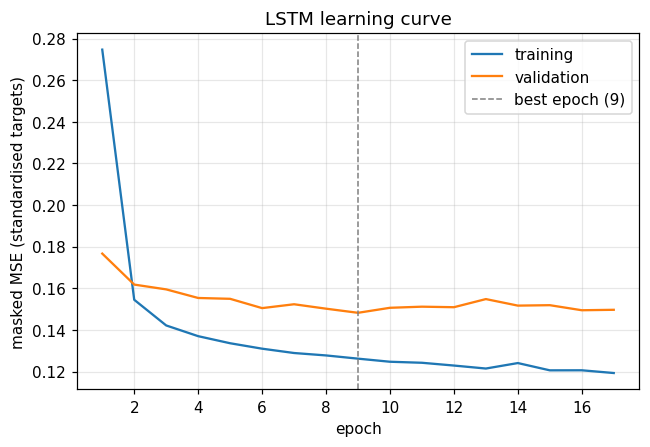

In [41]:
fig, ax = plt.subplots(figsize=(6.6, 4.2))
h = sel_run["history"]
ax.plot(h.epoch, h.train_loss, label="training")
ax.plot(h.epoch, h.val_loss, label="validation")
ax.axvline(sel_run["best_epoch"], color="grey", ls="--", lw=1,
           label=f"best epoch ({sel_run['best_epoch']})")
ax.set(xlabel="epoch", ylabel="masked MSE (standardised targets)",
       title=f"{SELECTED} learning curve")
ax.legend()
save(fig, "p2_2_learning_curve.png")
plt.show()

### Test evaluation: October unsealed once

The pipeline above is now fixed. The test partition is evaluated a single time, and
nothing below feeds back into any earlier decision.

In [42]:
Pz, Yz, Mt = predict_split(sel_run["model"], DS["test"])
test_pred, test_true = to_original(Pz), to_original(Yz)
if CLIP:
    test_pred = np.clip(test_pred, 0, None)

te = masked_metrics(test_pred, test_true, Mt)
print(f"{SELECTED}: test MAE {te['mae']:.4f}  RMSE {te['rmse']:.4f}  "
      f"bias {te['bias']:+.4f}  over {te['n']:,} observed target entries")

_ok = Mt.astype(bool)
print(f"independent NumPy check: MAE "
      f"{np.abs(test_pred[_ok] - test_true[_ok]).mean():.6f}  RMSE "
      f"{np.sqrt(((test_pred[_ok] - test_true[_ok]) ** 2).mean()):.6f}")

hz = per_horizon(test_pred, test_true, Mt)
hz_tbl = pd.DataFrame([{"horizon": f"+{15 * (i + 1)} min", "MAE": h["mae"],
                        "RMSE": h["rmse"], "bias": h["bias"]}
                       for i, h in enumerate(hz)])
hz_tbl.to_csv(RES_DIR / "p2_2_test_horizon.csv", index=False)
print()
print(hz_tbl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

record("2.2", "test_mae", te["mae"], SELECTED)
record("2.2", "test_rmse", te["rmse"], SELECTED)
record("2.2", "test_bias", te["bias"], SELECTED)
for i, h in enumerate(hz):
    record("2.2", f"test_mae_h{i + 1}", h["mae"], f"+{15 * (i + 1)} min")

LSTM: test MAE 6.6880  RMSE 9.8475  bias -0.4760  over 234,576 observed target entries
independent NumPy check: MAE 6.687998  RMSE 9.847461

horizon    MAE    RMSE    bias
+15 min 6.4438  9.4335 -0.2559
+30 min 6.6672  9.8259 -0.4855
+45 min 6.7608  9.9702 -0.5566
+60 min 6.8801 10.1463 -0.6061


In [43]:
# Baselines on exactly the same October targets and mask
tix = DS["test"].target_index()
rows = [{"model": SELECTED, "test_MAE": te["mae"], "test_RMSE": te["rmse"],
         "test_bias": te["bias"]}]
for name, pred in baseline_predictions(DS["test"]).items():
    mm = masked_metrics(pred, test_true, Mt)
    rows.append({"model": name, "test_MAE": mm["mae"], "test_RMSE": mm["rmse"],
                 "test_bias": mm["bias"]})
test_tbl = pd.DataFrame(rows)
test_tbl.to_csv(RES_DIR / "p2_2_test_comparison.csv", index=False)
print(test_tbl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
for _, r in test_tbl.iterrows():
    k = r["model"].split()[0].lower().replace("-", "")
    record("2.2", f"test_{k}_mae", r["test_MAE"], "October")
    record("2.2", f"test_{k}_bias", r["test_bias"], "October")

print("\nbias = mean(prediction - truth); negative means under-prediction")
print(f"negative predictions on test: {(test_pred < 0).mean():.4%}, "
      f"most negative {test_pred.min():.3f}")

per_loc = pd.DataFrame({
    "location": LOCS,
    "mean_demand": [np.nanmean(np.where(OBSERVED[tix][:, :, i],
                                        DEMAND[tix][:, :, i], np.nan))
                    for i in range(len(LOCS))],
    "test_MAE": [masked_metrics(test_pred[:, :, i], test_true[:, :, i],
                                Mt[:, :, i])["mae"] for i in range(len(LOCS))]})
per_loc["MAE_pct_of_mean"] = 100 * per_loc.test_MAE / per_loc.mean_demand
per_loc.to_csv(RES_DIR / "p2_2_test_per_location.csv", index=False)
print()
print(per_loc.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

                    model  test_MAE  test_RMSE  test_bias
                     LSTM    6.6880     9.8475    -0.4760
              Persistence    9.7614    14.2695    -0.0026
Seasonal naive (t-1 week)    9.7410    15.0859    -1.2891
       Historical Average    8.2766    12.5488    -4.5234

bias = mean(prediction - truth); negative means under-prediction
negative predictions on test: 0.0000%, most negative 0.000



 location  mean_demand  test_MAE  MAE_pct_of_mean
      132       38.145     7.433           19.486
      138       30.610     7.014           22.914
      142       37.457     6.653           17.760
      161       51.199     7.258           14.176
      162       37.191     5.888           15.832
      170       34.307     5.355           15.608
      186       31.947     6.995           21.894
      230       37.872     6.212           16.401
      236       52.929     7.141           13.491
      237       54.864     6.960           12.686


saved -> figures\p2_2_forecast_example.png


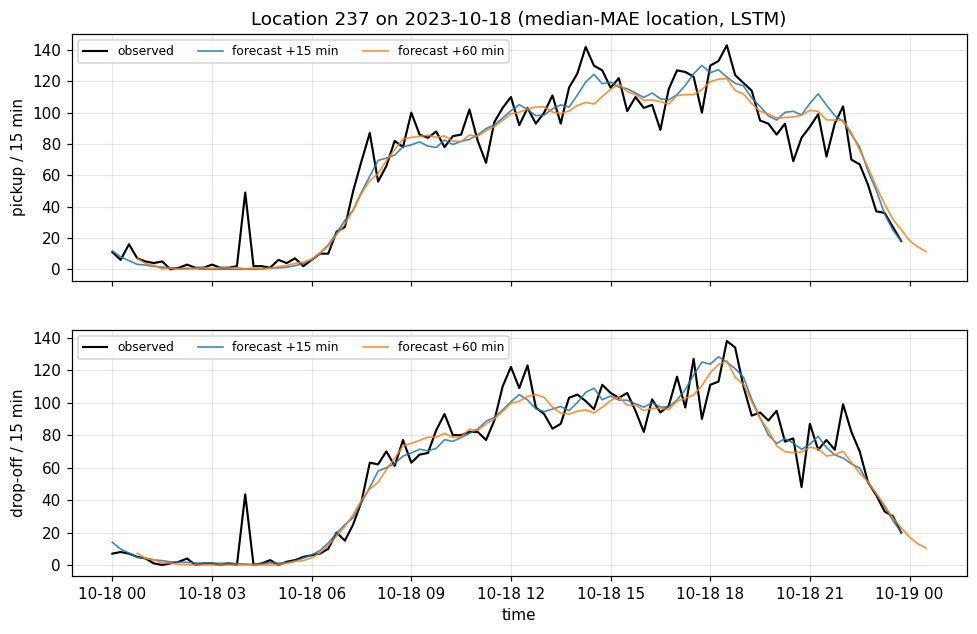

In [44]:
# Forecast example. The interval is chosen by a rule fixed in advance - the
# location with median test MAE, on the median-demand weekday - so the figure is
# representative rather than flattering.
med_loc = int(per_loc.test_MAE.rank(method="first").eq(
    (len(LOCS) + 1) // 2).idxmax())
day = pd.Timestamp("2023-10-18")            # a Wednesday in the middle of October
sel = (GRID[tix[:, 0]] >= day) & (GRID[tix[:, 0]] < day + pd.Timedelta("1D"))
idx = np.where(sel)[0]

fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.4), sharex=True)
for ch, (ax, lbl) in enumerate(zip(axes, ("pickup", "drop-off"))):
    t = GRID[tix[idx, 0]]
    ax.plot(t, test_true[idx, 0, med_loc, ch], color="black", lw=1.4,
            label="observed")
    for h in (0, 3):
        ax.plot(GRID[tix[idx, h]], test_pred[idx, h, med_loc, ch], lw=1.1,
                alpha=0.85, label=f"forecast +{15 * (h + 1)} min")
    ax.set(ylabel=f"{lbl} / 15 min")
    ax.legend(fontsize=8, ncol=3)
axes[0].set_title(f"Location {LOCS[med_loc]} on {day.date()} "
                  f"(median-MAE location, {SELECTED})")
axes[1].set_xlabel("time")
save(fig, "p2_2_forecast_example.png")
plt.show()

# Problem 3: Finding a charging station (30 points)

The road network is a $3\times3$ grid of nine nodes. Each move must go to an
adjacent node; staying put is not allowed. The reward of a move is set by the
congestion level of the road taken, and arriving at node 3 additionally pays $+10$.

| Congestion | Reward | Roads |
|---|---|---|
| None | $-1$ | 2–3, 4–5, 8–9 |
| Low | $-3$ | 1–2, 2–5, 3–6, 4–7, 5–8 |
| High | $-5$ | 1–4, 5–6, 7–8, 6–9 |

The congestion level of each road was read from Figure 1 of the problem sheet by
sampling the pixel colour of every edge against the three legend swatches; the
classification was unambiguous for all twelve roads.

Node 3 is treated as **terminal**: the episode ends when Emily reaches the charging
station, so $v(3)=0$ throughout. The problem describes node 3 as the destination and
pays a one-off arrival bonus, which only makes sense if the episode stops there.

In [45]:
from fractions import Fraction as F

NO, LOW, HIGH = -1, -3, -5
EDGES = {(1, 2): LOW, (2, 3): NO, (4, 5): NO, (5, 6): HIGH,
         (7, 8): HIGH, (8, 9): NO, (1, 4): HIGH, (2, 5): LOW,
         (3, 6): LOW, (4, 7): LOW, (5, 8): LOW, (6, 9): HIGH}
GOAL, BONUS = 3, 10

ADJ = {s: [] for s in range(1, 10)}
for (a, b) in EDGES:
    ADJ[a].append(b)
    ADJ[b].append(a)
for s in ADJ:
    ADJ[s].sort()


def road(a, b):
    return EDGES[(a, b)] if (a, b) in EDGES else EDGES[(b, a)]


def reward(a, b):
    """Road reward plus the one-off bonus for arriving at the charging station."""
    return road(a, b) + (BONUS if b == GOAL else 0)


print(pd.DataFrame([{"node": s, "moves": len(ADJ[s]),
                     "transitions": ", ".join(f"{s}->{n} ({reward(s, n):+d})"
                                              for n in ADJ[s])}
                    for s in range(1, 10)]).to_string(index=False))

 node  moves                                transitions
    1      2                       1->2 (-3), 1->4 (-5)
    2      3            2->1 (-3), 2->3 (+9), 2->5 (-3)
    3      2                       3->2 (-1), 3->6 (-3)
    4      3            4->1 (-5), 4->5 (-1), 4->7 (-3)
    5      4 5->2 (-3), 5->4 (-1), 5->6 (-5), 5->8 (-3)
    6      3            6->3 (+7), 6->5 (-5), 6->9 (-5)
    7      2                       7->4 (-3), 7->8 (-5)
    8      3            8->5 (-3), 8->7 (-5), 8->9 (-1)
    9      2                       9->6 (-5), 9->8 (-1)


## 3.1 Discounted return of a given route (6 points)

For the trajectory $7\to8\to5\to2\to3$ the return is
$G=\sum_{k}\gamma^{k}r_{k}$ with $\gamma=0.9$, where the last move collects the
$+10$ bonus on top of the road reward.

In [46]:
route = [7, 8, 5, 2, 3]
gamma = 0.9
rows, G = [], 0.0
for k in range(len(route) - 1):
    r = reward(route[k], route[k + 1])
    rows.append({"step k": k, "move": f"{route[k]} -> {route[k + 1]}",
                 "road": {NO: "none", LOW: "low", HIGH: "high"}[road(route[k], route[k + 1])],
                 "reward": r, "gamma^k": gamma ** k,
                 "contribution": gamma ** k * r})
    G += gamma ** k * r
p31 = pd.DataFrame(rows)
p31.to_csv(RES_DIR / "p3_1_return.csv", index=False)
print(p31.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nG = " + " + ".join(f"{r['gamma^k']:g}({r['reward']:+d})" for r in rows))
print(f"G = {G:.4f}")
record("3.1", "discounted_return", float(G), "route 7-8-5-2-3, gamma = 0.9")

 step k   move road  reward  gamma^k  contribution
      0 7 -> 8 high      -5   1.0000       -5.0000
      1 8 -> 5  low      -3   0.9000       -2.7000
      2 5 -> 2  low      -3   0.8100       -2.4300
      3 2 -> 3 none       9   0.7290        6.5610

G = 1(-5) + 0.9(-3) + 0.81(-3) + 0.729(+9)
G = -3.5690


-3.569

## 3.2 Uniform random policy (5 points)

With no knowledge of the network Emily picks uniformly among the admissible moves,
so $\pi(a\mid s)=1/|\mathcal{A}(s)|$. Each move is deterministic, so the state
transition probability equals the action probability.

In [47]:
rows = []
for s in (5, 6, 9):
    n = len(ADJ[s])
    for m in ADJ[s]:
        rows.append({"state": s, "action": f"move to {m}", "pi(a|s)": F(1, n),
                     "P(s'|s,a)": 1.0, "P(s'|s) under pi": F(1, n),
                     "reward": reward(s, m)})
p32 = pd.DataFrame(rows)
p32.to_csv(RES_DIR / "p3_2_policy.csv", index=False)
print(p32.to_string(index=False))
for s in (5, 6, 9):
    record("3.2", f"n_actions_node{s}", len(ADJ[s]), "admissible moves")

 state    action pi(a|s)  P(s'|s,a) P(s'|s) under pi  reward
     5 move to 2     1/4        1.0              1/4      -3
     5 move to 4     1/4        1.0              1/4      -1
     5 move to 6     1/4        1.0              1/4      -5
     5 move to 8     1/4        1.0              1/4      -3
     6 move to 3     1/3        1.0              1/3       7
     6 move to 5     1/3        1.0              1/3      -5
     6 move to 9     1/3        1.0              1/3      -5
     9 move to 6     1/2        1.0              1/2      -5
     9 move to 8     1/2        1.0              1/2      -1


## 3.3 Two sweeps of iterative policy evaluation (12 points)

Undiscounted, $\gamma=1$, starting from $v_0(s)=0$. The Bellman **expectation**
equation for the uniform random policy is

$$v_{k+1}(s)=\sum_{a}\pi(a\mid s)\Big[r(s,a)+\gamma\,v_k(s')\Big]
=\frac{1}{|\mathcal{A}(s)|}\sum_{s'\in\mathcal{N}(s)}\Big[r(s,s')+v_k(s')\Big].$$

Sweeps are synchronous: both updates use $v_k$ on the right-hand side, so the result
does not depend on the order in which states are visited. Values are kept as exact
fractions to avoid rounding.

In [48]:
v = {s: F(0) for s in range(1, 10)}
history = {0: dict(v)}
for k in (1, 2):
    v = {s: F(0) if s == GOAL else
         sum(F(1, len(ADJ[s])) * (reward(s, m) + v[m]) for m in ADJ[s])
         for s in range(1, 10)}
    history[k] = dict(v)

p33 = pd.DataFrame({f"v_{k}": {s: str(history[k][s]) for s in range(1, 10)}
                    for k in (0, 1, 2)})
p33.index.name = "state"
p33.to_csv(RES_DIR / "p3_3_policy_evaluation.csv")
print(p33.to_string())
print("\nas decimals:")
print(pd.DataFrame({f"v_{k}": {s: float(history[k][s]) for s in range(1, 10)}
                    for k in (0, 1, 2)}).to_string(float_format=lambda x: f"{x:+.4f}"))

print("\nworked example, v_2(2):")
print("  v_2(2) = 1/3[(-3 + v_1(1)) + (+9 + v_1(3)) + (-3 + v_1(5))]")
print(f"         = 1/3[({-3} + {history[1][1]}) + ({9} + {history[1][3]}) "
      f"+ ({-3} + {history[1][5]})] = {history[2][2]} = {float(history[2][2]):.4f}")
for s in range(1, 10):
    record("3.3", f"v1_node{s}", float(history[1][s]), "after sweep 1")
    record("3.3", f"v2_node{s}", float(history[2][s]), "after sweep 2")

      v_0 v_1    v_2
state               
1       0  -4     -5
2       0   1   -4/3
3       0   0      0
4       0  -3  -20/3
5       0  -3   -9/2
6       0  -1     -3
7       0  -4     -7
8       0  -3  -19/3
9       0  -3     -5

as decimals:
      v_0     v_1     v_2
1 +0.0000 -4.0000 -5.0000
2 +0.0000 +1.0000 -1.3333
3 +0.0000 +0.0000 +0.0000
4 +0.0000 -3.0000 -6.6667
5 +0.0000 -3.0000 -4.5000
6 +0.0000 -1.0000 -3.0000
7 +0.0000 -4.0000 -7.0000
8 +0.0000 -3.0000 -6.3333
9 +0.0000 -3.0000 -5.0000

worked example, v_2(2):
  v_2(2) = 1/3[(-3 + v_1(1)) + (+9 + v_1(3)) + (-3 + v_1(5))]
         = 1/3[(-3 + -4) + (9 + 0) + (-3 + -3)] = -4/3 = -1.3333


## 3.4 Greedy policy and whether it is optimal (7 points)

The greedy policy takes $\arg\max_a\big[r(s,a)+v_2(s')\big]$ at every state.

In [49]:
v2 = history[2]
qrows, greedy = [], {}
for s in range(1, 10):
    if s == GOAL:
        continue
    q = {m: reward(s, m) + v2[m] for m in ADJ[s]}
    best = max(q.values())
    greedy[s] = [m for m in q if q[m] == best]
    qrows.append({"state": s,
                  **{f"-> {m}": float(q[m]) for m in ADJ[s]},
                  "greedy": ", ".join(map(str, greedy[s]))})
p34 = pd.DataFrame(qrows)
p34.to_csv(RES_DIR / "p3_4_greedy.csv", index=False)
print(p34.to_string(index=False, float_format=lambda v: f"{v:+.3f}", na_rep=""))
print("\ngreedy policy:", {s: greedy[s][0] for s in sorted(greedy)})

 state   -> 2    -> 4 greedy    -> 1   -> 3   -> 5    -> 7   -> 6    -> 8    -> 9
     1 -4.333 -11.667      2                                                     
     2                     3  -8.000 +9.000 -7.500                               
     4                     5 -10.000        -5.500 -10.000                       
     5 -4.333  -7.667      2                               -8.000  -9.333        
     6                     3         +7.000 -9.500                        -10.000
     7         -9.667      4                                      -11.333        
     8                     9                -7.500 -12.000                 -6.000
     9                     8                               -8.000  -7.333        

greedy policy: {1: 2, 2: 3, 4: 5, 5: 2, 6: 3, 7: 4, 8: 9, 9: 8}


In [50]:
# Optimal policy by value iteration, for comparison only.
vstar = {s: F(0) for s in range(1, 10)}
for _ in range(100):
    nv = {s: F(0) if s == GOAL else max(reward(s, m) + vstar[m] for m in ADJ[s])
          for s in range(1, 10)}
    if nv == vstar:
        break
    vstar = nv
opt = {s: [m for m in ADJ[s]
           if reward(s, m) + vstar[m] == max(reward(s, n) + vstar[n]
                                             for n in ADJ[s])]
       for s in range(1, 10) if s != GOAL}
print("optimal values v*(s):", {s: int(vstar[s]) for s in range(1, 10)})
print("optimal policy     :", {s: opt[s] for s in sorted(opt)})

differ = [s for s in greedy if not set(greedy[s]) <= set(opt[s])]
print(f"\nstates where the greedy policy is not optimal: {differ}")

print("\nfollowing the greedy policy from every start:")
reach = {}
for s in range(1, 10):
    if s == GOAL:
        continue
    seen, cur, path = set(), s, [s]
    while cur != GOAL and cur not in seen:
        seen.add(cur)
        cur = greedy[cur][0]
        path.append(cur)
    reach[s] = cur == GOAL
    print(f"  from {s}: {' -> '.join(map(str, path))}"
          f"{'' if reach[s] else '   <-- cycles, never arrives'}")
record("3.4", "n_states_not_optimal", len(differ), "greedy(v2) vs value iteration")
record("3.4", "n_states_reaching_goal", int(sum(reach.values())),
    f"of {len(reach)} non-terminal states")

optimal values v*(s): {1: 6, 2: 9, 3: 0, 4: 5, 5: 6, 6: 7, 7: 2, 8: 3, 9: 2}
optimal policy     : {1: [2], 2: [3], 4: [5], 5: [2], 6: [3], 7: [4], 8: [5], 9: [6, 8]}

states where the greedy policy is not optimal: [8]

following the greedy policy from every start:
  from 1: 1 -> 2 -> 3
  from 2: 2 -> 3
  from 4: 4 -> 5 -> 2 -> 3
  from 5: 5 -> 2 -> 3
  from 6: 6 -> 3
  from 7: 7 -> 4 -> 5 -> 2 -> 3
  from 8: 8 -> 9 -> 8   <-- cycles, never arrives
  from 9: 9 -> 8 -> 9   <-- cycles, never arrives


6

saved -> figures\p3_4_greedy_policy.png


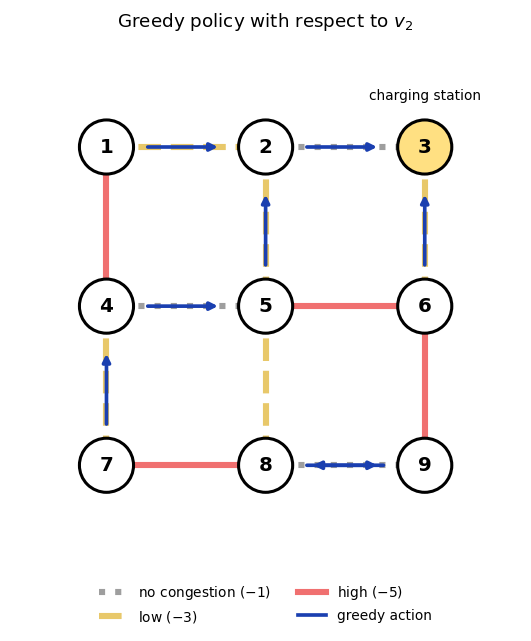

In [51]:
POS = {n: ((n - 1) % 3, -((n - 1) // 3)) for n in range(1, 10)}
COL = {NO: ("#9e9e9e", ":"), LOW: ("#e8c86a", "--"), HIGH: ("#f07070", "-")}

fig, ax = plt.subplots(figsize=(6.2, 6.2))
for (a, b), lev in EDGES.items():
    c, ls = COL[lev]
    (x1, y1), (x2, y2) = POS[a], POS[b]
    ax.plot([x1, x2], [y1, y2], color=c, ls=ls, lw=4, zorder=1,
            solid_capstyle="round")
for s, choices in sorted(greedy.items()):
    m = choices[0]                       # greedy[s] is a list of tied best moves
    (x1, y1), (x2, y2) = POS[s], POS[m]
    dx, dy = x2 - x1, y2 - y1
    ax.annotate("", xy=(x1 + 0.72 * dx, y1 + 0.72 * dy),
                xytext=(x1 + 0.24 * dx, y1 + 0.24 * dy),
                arrowprops=dict(arrowstyle="-|>", lw=2.4, color="#1a3fb0"),
                zorder=3)
for n, (x, y) in POS.items():
    goal = n == GOAL
    ax.add_patch(plt.Circle((x, y), 0.17, fc="#ffe082" if goal else "white",
                            ec="black", lw=2, zorder=4))
    ax.text(x, y, str(n), ha="center", va="center", fontsize=13,
            fontweight="bold", zorder=5)
ax.text(POS[GOAL][0], POS[GOAL][1] + 0.30, "charging station", ha="center",
        fontsize=9)
handles = [plt.Line2D([], [], color=COL[l][0], ls=COL[l][1], lw=4, label=t)
           for l, t in ((NO, "no congestion ($-1$)"), (LOW, "low ($-3$)"),
                        (HIGH, "high ($-5$)"))]
handles.append(plt.Line2D([], [], color="#1a3fb0", lw=2.4, label="greedy action"))
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02),
          ncol=2, frameon=False, fontsize=9)
ax.set(xlim=(-0.6, 2.6), ylim=(-2.6, 0.7))
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Greedy policy with respect to $v_2$")
save(fig, "p3_4_greedy_policy.png")
plt.show()

# Problem 4: Convolution (30 points)

## 4.1 Manual convolution (5 points)

With $I$ a $4\times4$ image and $K$ a $3\times3$ filter, stride 1 and no padding, the
output size is

$$\left\lfloor\frac{H-k_h}{s}\right\rfloor+1=\frac{4-3}{1}+1=2
\quad\text{in each dimension, so a }2\times2\text{ result.}$$

Each output entry is the sum of the elementwise product of $K$ with the corresponding
$3\times3$ window. Every window of $I$ contains three rows of $(10,10,0)$ or
$(10,0,0)$, and $K$ has columns $(+1,0,-1)$, so each row of a window contributes
$10-0=10$ and each window totals $30$:

$$I * K=\begin{pmatrix}30 & 30\\ 30 & 30\end{pmatrix}.$$

**Convention.** This is cross-correlation, which is what convolutional layers in
CNNs compute and what the function in 4.2 implements. A true mathematical
convolution first rotates the kernel by $180^\circ$; here that maps the columns
$(+1,0,-1)$ to $(-1,0,+1)$ and flips the sign of every output entry, giving
$-30$ throughout. Both are reported below so the convention is explicit.

**Interpretation.** $K$ differences the left column of a window against the right
column, so it responds to intensity change in the horizontal direction, that is to
*vertical* edges. Image $I$ is bright in columns 1–2 and dark in columns 3–4, a
single vertical edge between them. The response is large and positive because the
transition runs bright to dark from left to right, and it is *constant down each
column* because nothing varies vertically: the filter has located a vertical edge
spanning the full height of the image. A filter tuned to horizontal edges would
return zeros here.

In [52]:
I_img = np.array([[10, 10, 0, 0]] * 4)
K_edge = np.array([[1, 0, -1]] * 3)
print("I =\n", I_img, "\n\nK =\n", K_edge)
print(f"\noutput size = (4 - 3)/1 + 1 = {(4 - 3) // 1 + 1} in each dimension")
for r in range(2):
    for c in range(2):
        w = I_img[r:r + 3, c:c + 3]
        print(f"  window at ({r},{c}): sum(window * K) = {(w * K_edge).sum()}")

I =
 [[10 10  0  0]
 [10 10  0  0]
 [10 10  0  0]
 [10 10  0  0]] 

K =
 [[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

output size = (4 - 3)/1 + 1 = 2 in each dimension
  window at (0,0): sum(window * K) = 30
  window at (0,1): sum(window * K) = 30
  window at (1,0): sum(window * K) = 30
  window at (1,1): sum(window * K) = 30


## 4.2 Convolution from scratch (12 points)

`conv2d(image, kernel, stride=1, padding=0)` uses only NumPy array operations. No
built-in convolution routine is used anywhere in this problem. Correctness is
checked against an independent quadruple-loop implementation written separately, and
against the hand calculation of 4.1.

In [53]:
def conv2d(image, kernel, stride=1, padding=0):
    """2-D cross-correlation, the operation convolutional layers actually apply.

    A true mathematical convolution is obtained by passing kernel[::-1, ::-1].
    Zero padding and arbitrary stride are supported. Output size is
    (H + 2p - kh)//s + 1 by (W + 2p - kw)//s + 1.
    """
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError("conv2d expects a 2-D image and a 2-D kernel")
    kh, kw = kernel.shape
    if padding:
        image = np.pad(image, padding, mode="constant", constant_values=0.0)
    H, W = image.shape
    oh, ow = (H - kh) // stride + 1, (W - kw) // stride + 1
    if oh <= 0 or ow <= 0:
        raise ValueError("kernel is larger than the padded image")
    win = np.lib.stride_tricks.sliding_window_view(image, (kh, kw))[::stride,
                                                                   ::stride]
    return np.einsum("ijkl,kl->ij", win[:oh, :ow], kernel)


def conv2d_reference(image, kernel, stride=1, padding=0):
    """Deliberately naive version, written independently to check conv2d."""
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    kh, kw = kernel.shape
    if padding:
        image = np.pad(image, padding, mode="constant")
    H, W = image.shape
    out = np.zeros(((H - kh) // stride + 1, (W - kw) // stride + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            total = 0.0
            for m in range(kh):
                for n in range(kw):
                    total += image[i * stride + m, j * stride + n] * kernel[m, n]
            out[i, j] = total
    return out

In [54]:
cc = conv2d(I_img, K_edge)
tc = conv2d(I_img, K_edge[::-1, ::-1])
print("cross-correlation I*K (CNN convention):\n", cc.astype(int))
print("true convolution, kernel rotated 180 degrees:\n", tc.astype(int))
assert np.array_equal(cc, np.full((2, 2), 30.0))
assert np.array_equal(tc, np.full((2, 2), -30.0))
print("[PASS] matches the hand calculation of 4.1")
record("4.1", "cross_correlation_value", 30, "every entry of the 2x2 output")
record("4.1", "true_convolution_value", -30, "kernel rotated 180 degrees")

rng4 = np.random.default_rng(0)
worst, n_cases = 0.0, 0
for (H, W) in [(7, 9), (10, 10), (13, 8)]:
    for (kh, kw) in [(3, 3), (2, 4), (5, 5)]:
        for s in (1, 2, 3):
            for p in (0, 1, 2):
                eh, ew = (H + 2 * p - kh) // s + 1, (W + 2 * p - kw) // s + 1
                if eh <= 0 or ew <= 0:
                    continue
                img = rng4.normal(size=(H, W))
                ker = rng4.normal(size=(kh, kw))
                a = conv2d(img, ker, s, p)
                assert a.shape == (eh, ew), (a.shape, (eh, ew))
                worst = max(worst, np.abs(a - conv2d_reference(img, ker, s, p)).max())
                n_cases += 1
print(f"\n{n_cases} combinations of size, kernel, stride and padding:")
print(f"  every output shape equals (H + 2p - k)//s + 1")
print(f"  largest disagreement with the naive reference: {worst:.2e}")
record("4.2", "n_verification_cases", n_cases, "size x kernel x stride x padding")
record("4.2", "max_diff_vs_reference", float(worst), "vectorised vs naive loops")

cross-correlation I*K (CNN convention):
 [[30 30]
 [30 30]]
true convolution, kernel rotated 180 degrees:
 [[-30 -30]
 [-30 -30]]
[PASS] matches the hand calculation of 4.1

81 combinations of size, kernel, stride and padding:
  every output shape equals (H + 2p - k)//s + 1
  largest disagreement with the naive reference: 5.33e-15


5.329070518200751e-15

## 4.3 Applying image filters (8 points)

In [55]:
from skimage import data

rgb = data.astronaut()
print(f"skimage.data.astronaut(): shape {rgb.shape}, dtype {rgb.dtype}")
# luminance weights, applied explicitly rather than via a library helper
gray = (0.2125 * rgb[:, :, 0] + 0.7154 * rgb[:, :, 1]
        + 0.0721 * rgb[:, :, 2]) / 255.0
print(f"grayscale: shape {gray.shape}, range {gray.min():.3f} to {gray.max():.3f}")

SOBEL_X = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
SOBEL_Y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
gx = conv2d(gray, SOBEL_X, stride=1, padding=1)
gy = conv2d(gray, SOBEL_Y, stride=1, padding=1)
print(f"\nstride 1, padding 1 -> output {gx.shape}, input preserved: "
      f"{gx.shape == gray.shape}")
print(f"Kx: range {gx.min():+.3f} to {gx.max():+.3f}, mean |response| "
      f"{np.abs(gx).mean():.4f}")
print(f"Ky: range {gy.min():+.3f} to {gy.max():+.3f}, mean |response| "
      f"{np.abs(gy).mean():.4f}")
print(f"mean |dI/dx| in the image {np.abs(np.diff(gray, axis=1)).mean():.4f}, "
      f"mean |dI/dy| {np.abs(np.diff(gray, axis=0)).mean():.4f}")
print("\neffect of stride (padding 1):")
for s in (1, 2, 4):
    print(f"  stride {s}: output {conv2d(gray, SOBEL_X, s, 1).shape}")
record("4.3", "kx_mean_abs_response", float(np.abs(gx).mean()), "Sobel X")
record("4.3", "ky_mean_abs_response", float(np.abs(gy).mean()), "Sobel Y")

skimage.data.astronaut(): shape (512, 512, 3), dtype uint8
grayscale: shape (512, 512), range 0.000 to 1.000

stride 1, padding 1 -> output (512, 512), input preserved: True
Kx: range -3.719 to +3.786, mean |response| 0.1736
Ky: range -3.361 to +3.938, mean |response| 0.1441
mean |dI/dx| in the image 0.0272, mean |dI/dy| 0.0235

effect of stride (padding 1):
  stride 1: output (512, 512)
  stride 2: output (256, 256)
  stride 4: output (128, 128)


0.14406916633755554

saved -> figures\p4_3_sobel.png


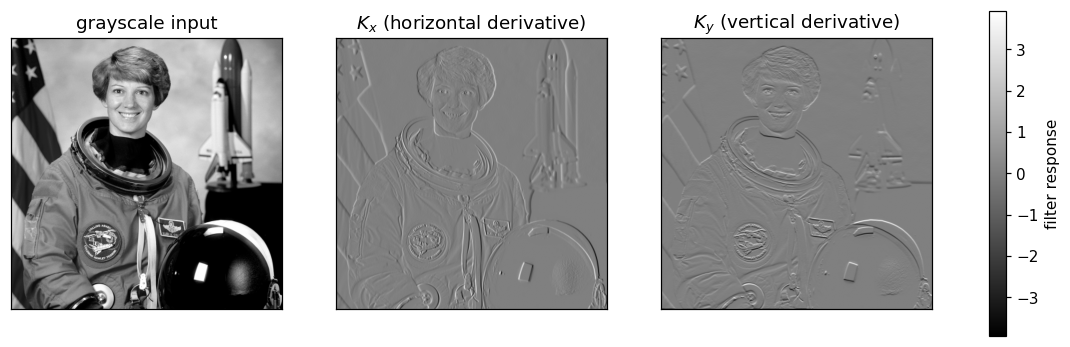

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.8))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("grayscale input")
lim = max(np.abs(gx).max(), np.abs(gy).max())
for ax, g, t in ((axes[1], gx, "$K_x$ (horizontal derivative)"),
                 (axes[2], gy, "$K_y$ (vertical derivative)")):
    im = ax.imshow(g, cmap="gray", vmin=-lim, vmax=lim)
    ax.set_title(t)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.8, label="filter response")
save(fig, "p4_3_sobel.png")
plt.show()

**Figure.** Grayscale input and the two Sobel responses, drawn on a common symmetric
scale so their magnitudes are comparable. $K_x$ differences the left and right
columns of each window, so it responds to intensity change along the horizontal axis
and highlights **vertical** structures: the edge of the shoulder, the upright
window frames, the vertical folds of the suit. $K_y$ differences the top and bottom
rows and therefore highlights **horizontal** structures: the rim of the helmet, the
horizontal bands in the background, the line of the collar. Edges running parallel
to a filter's difference direction produce almost no response, which is why the two
maps look close to complementary. Mid-grey means a response near zero; light and
dark indicate the two signs, that is whether intensity increases or decreases across
the edge.

## 4.4 Connection to CNNs (5 points)

The Sobel kernels used above are **fixed**: their nine weights were chosen by hand,
decades ago, to approximate a first derivative of image intensity, and they are the
same for every image. They encode one specific, human-specified notion of what is
worth measuring.

A convolutional layer in a CNN performs the identical arithmetic (the same sliding
window, the same elementwise products and sum, the same stride and padding rules
implemented in 4.2), but its kernel entries are **parameters, initialised randomly
and learned by gradient descent**. Each weight receives a gradient of the loss
through backpropagation, exactly as the MLP weights did in Problem 1, and is updated
to reduce that loss. Nobody specifies that a kernel should detect edges; if edge
detection helps minimise the training objective, filters resembling Sobel operators
tend to emerge on their own in the first layer, and if something else is more useful,
something else emerges instead.

Three consequences matter for a task such as image classification. First, the
features are optimised for the actual objective rather than chosen in advance, so
they can capture patterns nobody thought to hand-code. Second, a layer holds many
kernels and layers are stacked, so later layers convolve over earlier feature maps
and build a hierarchy of edges, then corners and textures, then object parts, which
would be impractical to design by hand. Third, weight sharing keeps this affordable:
one $3\times3$ kernel is nine parameters regardless of image size, and the same
detector applies at every position, so a pattern learned in one part of the image is
recognised anywhere in it. A fully connected layer over a $512\times512$ image would
need hundreds of thousands of weights per unit and would have to learn each position
separately.

In [57]:
reg = pd.DataFrame(REPORTED)
reg.to_csv(RES_DIR / "reported_values.csv", index=False)
print(f"{len(reg)} values quoted in the report, collected in "
      f"{RES_DIR / 'reported_values.csv'}\n")
print(reg.to_string(index=False))

126 values quoted in the report, collected in results\reported_values.csv

problem                            metric         value                                          note
    1.1      gradient_check_max_rel_error  5.096971e-09                 central differences, eps=1e-6
    1.1             autograd_max_abs_diff  2.775558e-17                   PyTorch float64 cross-check
    1.1            test_majority_baseline  5.333333e-01 majority-class accuracy on the 60 test points
    1.1          default_final_train_loss  6.902790e-01                            lr=0.001, 20000 ep
    1.1            default_train_accuracy  5.500000e-01                                      lr=0.001
    1.1             default_test_accuracy  3.833333e-01                                      lr=0.001
    1.1          sweep_best_learning_rate  1.000000e+01                    lowest final training loss
    1.1          sweep_best_test_accuracy  7.833333e-01                                       lr=10.0
    1.2